# Assignment 4 — Predicting PM2.5 Concentrations from AirQo Sensor Data
**CSC3119: AI Deployment & Scalability · Uganda Christian University**

This notebook is the complete, reproducible pipeline for the assignment:

| Stage | Section | Output |
|---|---|---|
| 0 | Setup, configuration, run logging | `outputs/logs/pipeline_run.log` |
| 1 | Data loading & schema audit | raw data profile |
| 2 | Data preparation (nulls, coordinates, outliers, hourly resampling, dtypes, imputation) | `data/processed/*.parquet` |
| 3 | Exploratory data analysis (5 Kampala sensors, AQI calendar & time-series plots, Z-scores, correlations) | `outputs/figures/` |
| 4 | Machine learning — 5 tuned models + stacking ensemble, metrics, best-model selection | `models/best_pm25_model.joblib` |
| 5 | Forecasting August 2026 (daily 2 weeks + hourly 1 Aug), inverse Z-score, AQI visualisations, bonus map | `outputs/forecasts/` |
| 6 | Model monitoring with Evidently AI (data drift + model drift) | `outputs/evidently/*.html` |
| 7 | Deployment on RunPod (runtime log, environment capture, instructions) | `deployment/` |

> **Run order:** top to bottom. The notebook was debugged locally end-to-end before deployment, as the brief requires.
> Every heavy or optional step (Evidently, GPU detection, shapefile map) is wrapped in `try/except` so the pipeline **never crashes** ("thou shall not crash").

## 0. Setup & configuration

In [1]:
import os, sys, json, time, math, logging, platform, warnings, calendar, subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import joblib
try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.model_selection import GroupKFold, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- paths (relative so the same notebook runs locally and on RunPod) ----
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA_RAW = ROOT / "data" / "sensor_data_jan_jul_2026.csv"
SHAPE_DIR = ROOT / "data" / "shapefiles"
PROC_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
FC_DIR = ROOT / "outputs" / "forecasts"
EV_DIR = ROOT / "outputs" / "evidently"
LOG_DIR = ROOT / "outputs" / "logs"
MODEL_DIR = ROOT / "models"
for d in [PROC_DIR, FIG_DIR, FC_DIR, EV_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- study window & forecast window (local Kampala time, EAT = UTC+3) ----
LOCAL_TZ = "Africa/Kampala"
WINDOW_START, WINDOW_END = "2026-01-01 00:00", "2026-07-31 23:00"
# "First two full weeks of August": Aug 1-14 if counted from the 1st, or Mon 3 - Sun 16 Aug if counted
# as calendar weeks. We forecast 1-16 Aug so that BOTH interpretations are covered.
FC_DAILY_START, FC_DAILY_END = "2026-08-01", "2026-08-16"
FC_HOURLY_DAY = "2026-08-01"
TEST_START = "2026-06-02 06:00"      # chronological hold-out = the last full 24 h observed (2 Jun 06:00 → 3 Jun 06:00)

# ---- AQI categories (Section 4 of the brief) ----
AQI_BINS = [0, 9.0, 35.49, 55.49, 125.49, 225.49, np.inf]
AQI_LABELS = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]
AQI_COLORS = ["#00e400", "#ffff00", "#ff7e00", "#ff0000", "#8f3f97", "#7e0023"]
AQI_RANGES = ["0–9", "9.1–35.49", "35.49–55.49", "55.49–125.49", "125.49–225.49", "> 225.49"]

def aqi_category(x):
    return pd.cut(x, bins=AQI_BINS, labels=AQI_LABELS, right=True, include_lowest=True)

def aqi_legend_handles():
    return [mpatches.Patch(color=c, label=f"{l} ({r} µg/m³)") for c, l, r in zip(AQI_COLORS, AQI_LABELS, AQI_RANGES)]

def add_aqi_bands(ax, ymax=None, alpha=0.18):
    ymax = ymax or ax.get_ylim()[1]
    for lo, hi, c in zip(AQI_BINS[:-1], AQI_BINS[1:], AQI_COLORS):
        if lo >= ymax:
            break
        ax.axhspan(lo, min(hi, ymax), color=c, alpha=alpha, zorder=0, lw=0)
    ax.set_ylim(0, ymax)

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})

# ---- runtime logger: same log is produced locally and on RunPod (deployment evidence) ----
logger = logging.getLogger("airqo_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(LOG_DIR / "pipeline_run.log", mode="w")
fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname)s | %(message)s"))
logger.addHandler(fh)
sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(logging.Formatter("[%(asctime)s] %(message)s", "%H:%M:%S"))
logger.addHandler(sh)

STAGE_TIMES = {}
class stage:
    """Context manager that times each pipeline stage and writes it to the run log."""
    def __init__(self, name): self.name = name
    def __enter__(self):
        self.t0 = time.perf_counter(); logger.info(f"START  {self.name}"); return self
    def __exit__(self, *exc):
        dt = time.perf_counter() - self.t0; STAGE_TIMES[self.name] = round(dt, 2)
        logger.info(f"END    {self.name}  ({dt:.1f}s)"); return False

PIPELINE_T0 = time.perf_counter()

def environment_info():
    info = {"python": sys.version.split()[0], "platform": platform.platform(),
            "processor": platform.processor() or platform.machine(), "cpu_count": os.cpu_count(),
            "pandas": pd.__version__, "numpy": np.__version__,
            "sklearn": __import__("sklearn").__version__, "xgboost": __import__("xgboost").__version__,
            "runpod_pod_id": os.environ.get("RUNPOD_POD_ID", "not on RunPod (local run)"),
            "gpu": "none detected"}
    try:
        out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
                             capture_output=True, text=True, timeout=10)
        if out.returncode == 0 and out.stdout.strip():
            info["gpu"] = out.stdout.strip()
    except Exception:
        pass
    return info

ENV = environment_info()
USE_GPU = ENV["gpu"] != "none detected"
for k, v in ENV.items():
    logger.info(f"ENV {k}: {v}")
print("GPU available for XGBoost:", USE_GPU)

[03:26:36] ENV python: 3.11.15


[03:26:36] ENV platform: Linux-6.18.44-fc-v64-x86_64-with-glibc2.39


[03:26:36] ENV processor: x86_64


[03:26:36] ENV cpu_count: 4


[03:26:36] ENV pandas: 3.0.6


...

[03:26:36] ENV sklearn: 1.9.1


[03:26:36] ENV xgboost: 3.2.0


[03:26:36] ENV runpod_pod_id: not on RunPod (local run)


[03:26:36] ENV gpu: none detected


GPU available for XGBoost: False


### Methodology pipeline (flow chart)

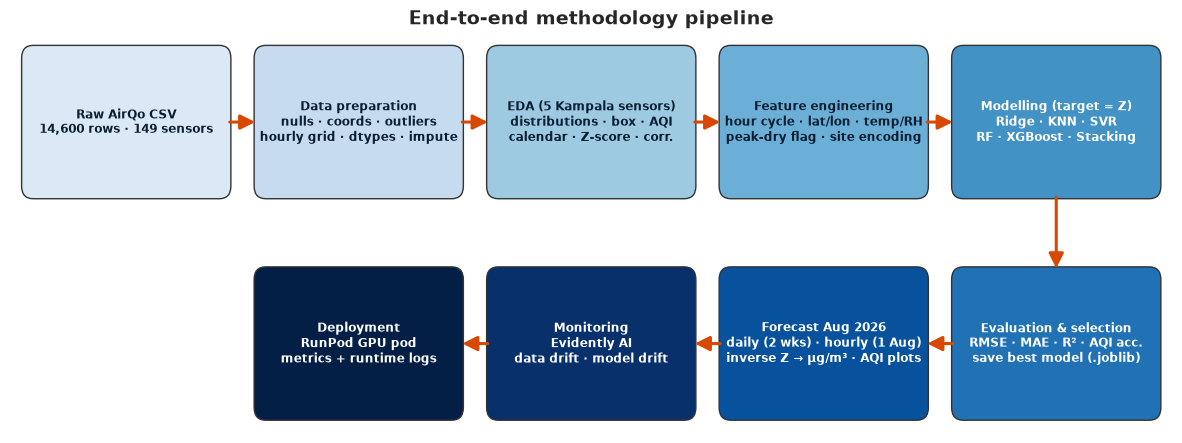

In [2]:
def draw_pipeline():
    steps = [("Raw AirQo CSV\n14,600 rows · 149 sensors", "#dbe9f6"),
             ("Data preparation\nnulls · coords · outliers\nhourly grid · dtypes · impute", "#c6dbef"),
             ("EDA (5 Kampala sensors)\ndistributions · box · AQI\ncalendar · Z-score · corr.", "#9ecae1"),
             ("Feature engineering\nhour cycle · lat/lon · temp/RH\npeak-dry flag · site encoding", "#6baed6"),
             ("Modelling (target = Z)\nRidge · KNN · SVR\nRF · XGBoost · Stacking", "#4292c6"),
             ("Evaluation & selection\nRMSE · MAE · R² · AQI acc.\nsave best model (.joblib)", "#2171b5"),
             ("Forecast Aug 2026\ndaily (2 wks) · hourly (1 Aug)\ninverse Z → µg/m³ · AQI plots", "#08519c"),
             ("Monitoring\nEvidently AI\ndata drift · model drift", "#08306b"),
             ("Deployment\nRunPod GPU pod\nmetrics + runtime logs", "#041f45")]
    fig, ax = plt.subplots(figsize=(15, 5.2)); ax.axis("off")
    n_top = 5
    pos = [(i * 3.0, 3.2) for i in range(n_top)] + [((n_top - 1 - i) * 3.0 - 1.5 + 1.5, 0.6) for i in range(len(steps) - n_top)]
    for i, ((txt, col), (x, y)) in enumerate(zip(steps, pos)):
        ax.add_patch(mpatches.FancyBboxPatch((x, y), 2.6, 1.7, boxstyle="round,pad=0.05,rounding_size=0.15",
                                             fc=col, ec="#333", lw=1))
        ax.text(x + 1.3, y + 0.85, txt, ha="center", va="center", fontsize=8.6,
                color="white" if i >= 4 else "#0b1f33", weight="bold")
        if i < len(steps) - 1:
            (x2, y2) = pos[i + 1]
            ap = dict(arrowstyle="-|>", lw=2.2, color="#d94801", mutation_scale=22, shrinkA=2, shrinkB=2)
            if i < n_top - 1:
                ax.annotate("", (x2, y + 0.85), (x + 2.6, y + 0.85), arrowprops=ap)
            elif i == n_top - 1:
                ax.annotate("", (x2 + 1.3, y2 + 1.7), (x + 1.3, y), arrowprops=ap)
            else:
                ax.annotate("", (x2 + 2.6, y2 + 0.85), (x, y + 0.85), arrowprops=ap)
    ax.set_xlim(-0.2, 14.8); ax.set_ylim(0.4, 5.1)
    ax.set_title("End-to-end methodology pipeline", fontsize=14)
    savefig(fig, "00_pipeline_flowchart"); plt.show()

draw_pipeline()

## 1. Load the raw data & audit the schema

In [3]:
with stage("1. load raw data"):
    raw = pd.read_csv(DATA_RAW)
print(raw.shape)
raw.head()

[03:26:36] START  1. load raw data


[03:26:36] END    1. load raw data  (0.1s)


(14600, 12)


,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5_calibrated_value,pm10_calibrated_value,site_id,device_name
0,Salama Road,2026-01-01 00:00:00Z,hourly,airgradient,0.33354,32.56861,20.535000,88.405000,181.16,197.89,694140834973ef0013d1a9b0,ag_588c81267534
1,Salama Road,2026-01-01 01:00:00Z,hourly,airgradient,0.33354,32.56861,20.640000,89.610000,290.98,318.91,694140834973ef0013d1a9b0,ag_588c81267534
2,Salama Road,2026-01-01 02:00:00Z,hourly,airgradient,0.33354,32.56861,20.821053,89.610526,274.59,301.09,694140834973ef0013d1a9b0,ag_588c81267534
3,Salama Road,2026-01-01 03:00:00Z,hourly,airgradient,0.33354,32.56861,20.605000,90.055000,242.30,264.05,694140834973ef0013d1a9b0,ag_588c81267534
4,Salama Road,2026-01-01 04:00:00Z,hourly,airgradient,0.33354,32.56861,20.675000,88.715000,206.34,225.85,694140834973ef0013d1a9b0,ag_588c81267534


In [4]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_empty": raw.isna().sum(),
    "n_zero": (raw == 0).sum(),
    "n_unique": raw.nunique(),
})
audit["pct_null_or_zero"] = ((audit.n_empty + audit.n_zero) / len(raw) * 100).round(1)
audit

,dtype,n_empty,n_zero,n_unique,pct_null_or_zero
site_name,str,0,0,145,0.0
datetime,str,0,0,147,0.0
frequency,str,0,0,1,0.0
network,str,0,0,2,0.0
latitude,float64,1,3085,4031,21.1
longitude,float64,0,3067,3900,21.0
temperature,float64,54,4066,6382,28.2
humidity,float64,206,4159,6681,29.9
pm2_5_calibrated_value,float64,325,0,5870,2.2
pm10_calibrated_value,float64,427,3,7634,2.9


In [5]:
ts_counts = raw["datetime"].str[:10].value_counts().sort_index()
print("Distinct dates present in the file:\n", ts_counts.to_string())
print("\nRecords per sensor:\n", raw.groupby("device_name").size().describe().round(1).to_string())

Distinct dates present in the file:
 datetime
2026-01-01    2398
2026-01-02    2554
2026-01-03      48
2026-04-01    2423
2026-04-02    2177
2026-06-01    2358
2026-06-02    2366
2026-06-03     276

Records per sensor:
 count    149.0
mean      98.0
std       39.6
min       20.0
25%       58.0
50%      105.0
75%      137.0
max      147.0


**Key audit findings (these drive every later decision):**

* The file is labelled *Jan–Jul 2026* but only contains **three short observation windows**: 1–3 Jan, 1–2 Apr and 1–3 Jun 2026 (147 distinct hourly timestamps). Everything in between is missing — the sensors' data was not delivered for those hours. When we resample to a full hourly index (Section 2.6) these become explicit *missing* rows, exactly as the brief asks.
* `temperature`/`humidity` have ~28% zeros and `latitude`/`longitude` ~21% zeros: per the brief, **0 means null**, not a genuine reading (Kampala is never 0 °C; no Ugandan sensor sits at 0°N 0°E).
* `frequency` is constant (`hourly`) → no information. `site_id` is ~51% empty and duplicates `site_name` → dropped. `network` (airqo vs airgradient hardware) is kept as a device-type indicator.
* PM2.5 has a maximum of 998.4 µg/m³ — a physically implausible sensor-saturation value (handled in 2.5).

## 2. Data preparation

### Literature guiding the cleaning decisions
* **Junninen et al. (2004)**, *Methods for imputation of missing values in air quality data sets*, Atmospheric Environment 38(18): univariate linear interpolation is the most accurate method for **short gaps (a few hours)**, while longer gaps require multivariate / spatial methods — and very long gaps should not be filled with synthetic values.
* **Okure et al. (2022)**, *Characterization of Ambient Air Quality in Selected Urban Areas in Uganda Using Low-Cost Sensing and Measurement Technologies*, Environ. Sci. Technol. 56(6) (AirQo team): describes AirQo device outages (power, 2G connectivity) and the use of hourly aggregates with completeness thresholds rather than gap-filling long outages.
* **Adong et al. (2022)**, *Applying machine learning for large-scale field calibration of low-cost PM2.5 and PM10 air pollution sensors*, Applied AI Letters 3(3) (AirQo team): the `*_calibrated_value` fields come from this ML calibration that already uses temperature and humidity — so we model the calibrated values directly and treat raw sensor artefacts (e.g. saturation) as invalid.
* **Barkjohn, Gantt & Clements (2021)**, *Development and application of a United States-wide correction for PM2.5 data collected with the PurpleAir sensor*, Atmos. Meas. Tech. 14: removes physically implausible low-cost sensor readings (very high values beyond the sensor's effective range) before modelling.

**Resulting policy**

| Situation | Action | Why |
|---|---|---|
| 0 or empty in temp, humidity, PM2.5, PM10, lat, lon | → `NaN` | Instruction in brief; 0 is a placeholder, not a measurement |
| PM2.5 > 500 µg/m³ | → `NaN` (logged) | Beyond low-cost optical sensor range (saturation), Barkjohn et al. 2021 |
| Statistical outliers (per-sensor IQR) | **flag, keep** | High values are real pollution episodes (Kampala peaks); removing them would bias forecasts low |
| Gap ≤ 3 h inside a sensor's record | linear time interpolation | Junninen et al. 2004 — accurate for short gaps |
| Gap > 3 h (device offline) | keep as `NaN` + `is_observed = 0` | Do not fabricate PM2.5 labels for long outages (Okure et al. 2022) |
| Missing temp/humidity at an observed hour | spatial IDW from the 3 nearest sensors at the same hour → sensor's hour-of-day median → city-wide hour median | weather is spatially smooth; neighbours are the best proxy (Junninen et al. 2004, multivariate methods) |
| Missing coordinates | per-device median of valid GPS fixes; documented gazetteer for 6 devices with no fix at all | sensors are fixed installations; GPS jitter averaged out |

In [6]:
with stage("2. data preparation"):
    df = raw.copy()

    # 2.1 Consistent dtypes --------------------------------------------------------
    df["datetime"] = (pd.to_datetime(df["datetime"], utc=True)
                        .dt.tz_convert(LOCAL_TZ).dt.tz_localize(None))   # local EAT, naive
    for c in ["site_name", "network", "device_name", "site_id", "frequency"]:
        df[c] = df[c].astype("string").str.strip()
    NUMERIC = ["latitude", "longitude", "temperature", "humidity", "pm2_5_calibrated_value", "pm10_calibrated_value"]
    df[NUMERIC] = df[NUMERIC].apply(pd.to_numeric, errors="coerce").astype("float64")

    # 2.2 Zero / empty -> NaN (brief, Section 5) -------------------------------------
    null_before = df[NUMERIC].isna().sum()
    df[NUMERIC] = df[NUMERIC].mask(df[NUMERIC] == 0)
    # a coordinate pair is only valid if BOTH parts are valid
    bad_xy = df["latitude"].isna() | df["longitude"].isna()
    df.loc[bad_xy, ["latitude", "longitude"]] = np.nan
    null_after = df[NUMERIC].isna().sum()

    # 2.3 Drop non-informative columns ---------------------------------------------
    df = df.drop(columns=["frequency", "site_id"])
    df = df.rename(columns={"pm2_5_calibrated_value": "pm2_5", "pm10_calibrated_value": "pm10"})

    # duplicates (same device & hour)
    n_dup = df.duplicated(["device_name", "datetime"]).sum()
    df = df.groupby(["device_name", "datetime"], as_index=False).agg(
        {"site_name": "first", "network": "first", "latitude": "median", "longitude": "median",
         "temperature": "mean", "humidity": "mean", "pm2_5": "mean", "pm10": "mean"})

pd.DataFrame({"nulls_before (empty only)": null_before, "nulls_after (empty + zero)": null_after})

[03:26:36] START  2. data preparation


[03:26:36] END    2. data preparation  (0.1s)


,nulls_before (empty only),nulls_after (empty + zero)
latitude,1,3086
longitude,0,3086
temperature,54,4120
humidity,206,4365
pm2_5_calibrated_value,325,325
pm10_calibrated_value,427,430


In [7]:
print("Duplicate device-hour rows merged:", n_dup)
df.dtypes

Duplicate device-hour rows merged: 0


device_name            string
datetime       datetime64[us]
site_name              string
network                string
latitude              float64
longitude             float64
temperature           float64
humidity              float64
pm2_5                 float64
pm10                  float64
dtype: object

### 2.4 Coordinates — one fixed location per sensor
Sensors are fixed installations, yet the GPS fixes jitter (up to 119 distinct values per device) and many are null.
We assign each device the **median** of its valid fixes (robust to jitter). Six devices never reported a valid fix; for these we use
approximate coordinates of the named site (documented gazetteer below, flagged `coords_imputed = True`). This follows the team's meeting note that
missing coordinates should converge to a central (median) value rather than be dropped.

In [8]:
GAZETTEER = {   # approximate site centroids (from the site name), used only when a device has NO valid GPS fix
    "airqo_g5367": (0.3133, 32.5560),   # Bakuli, Kampala
    "aq_43":       (0.2714, 32.5917),   # Makindye, Lukuli
    "aq_54":       (0.3536, 32.5672),   # Kalerwe, Kawempe
    "aq_79":       (0.3540, 32.6150),   # Ntinda, Nakawa
    "aq_g518":     (0.5000, 33.1500),   # Kivubuka Budondo, Jinja
    "aq_g5_50":    (-1.2400, 29.9900),  # Rushoroza Hill, Kabale
}
dev_xy = df.groupby("device_name")[["latitude", "longitude"]].median()
dev_xy["coords_imputed"] = dev_xy["latitude"].isna()
for dev, (la, lo) in GAZETTEER.items():
    if dev in dev_xy.index and dev_xy.loc[dev, "coords_imputed"]:
        dev_xy.loc[dev, ["latitude", "longitude"]] = [la, lo]
# final safety net: any device still without coordinates -> network median (meeting note: median imputation)
dev_xy["latitude"] = dev_xy["latitude"].fillna(dev_xy["latitude"].median())
dev_xy["longitude"] = dev_xy["longitude"].fillna(dev_xy["longitude"].median())
df = df.drop(columns=["latitude", "longitude"]).merge(dev_xy, left_on="device_name", right_index=True)
print("Devices with imputed coordinates:", dev_xy.coords_imputed.sum())
dev_xy[dev_xy.coords_imputed]

Devices with imputed coordinates: 6


,latitude,longitude,coords_imputed
device_name,,,
airqo_g5367,0.3133,32.5560,True
aq_43,0.2714,32.5917,True
aq_54,0.3536,32.5672,True
aq_79,0.3540,32.6150,True
aq_g518,0.5000,33.1500,True
aq_g5_50,-1.2400,29.9900,True


### 2.5 Physical validity checks & outlier flagging (kept track of, not silently removed)

In [9]:
outlier_log = []
def log_outliers(mask, field, rule, action):
    outlier_log.append({"field": field, "rule": rule, "n_rows": int(mask.sum()), "action": action})

m = df["pm2_5"] > 500
log_outliers(m, "pm2_5", "> 500 µg/m³ (sensor saturation)", "set to NaN")
df.loc[m, "pm2_5"] = np.nan
m = df["pm10"] > 1000
log_outliers(m, "pm10", "> 1000 µg/m³", "set to NaN"); df.loc[m, "pm10"] = np.nan
m = (df["temperature"] < 5) | (df["temperature"] > 45)
log_outliers(m, "temperature", "outside 5–45 °C", "set to NaN"); df.loc[m, "temperature"] = np.nan
m = (df["humidity"] < 5) | (df["humidity"] > 100)
log_outliers(m, "humidity", "outside 5–100 %", "set to NaN"); df.loc[m, "humidity"] = np.nan

# statistical outliers: per-sensor IQR fences (flag only)
def iqr_flag(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    return (s < q1 - k * (q3 - q1)) | (s > q3 + k * (q3 - q1))
df["pm25_outlier_iqr"] = df.groupby("device_name")["pm2_5"].transform(iqr_flag).astype(bool)
df["pm25_outlier_extreme"] = df.groupby("device_name")["pm2_5"].transform(lambda s: iqr_flag(s, 3)).astype(bool)
log_outliers(df.pm25_outlier_iqr, "pm2_5", "per-sensor 1.5×IQR fence", "flagged, KEPT (real episodes)")
log_outliers(df.pm25_outlier_extreme, "pm2_5", "per-sensor 3×IQR fence (extreme)", "flagged, KEPT")
m = df["pm2_5"] > df["pm10"] * 1.05
log_outliers(m, "pm2_5 vs pm10", "PM2.5 > PM10 (separate calibrations)", "flagged, kept (PM10 not a predictor)")
OUTLIER_LOG = pd.DataFrame(outlier_log)
OUTLIER_LOG

,field,rule,n_rows,action
0,pm2_5,> 500 µg/m³ (sensor saturation),3,set to NaN
1,pm10,> 1000 µg/m³,0,set to NaN
2,temperature,outside 5–45 °C,0,set to NaN
3,humidity,outside 5–100 %,0,set to NaN
4,pm2_5,per-sensor 1.5×IQR fence,650,"flagged, KEPT (real episodes)"
5,pm2_5,per-sensor 3×IQR fence (extreme),222,"flagged, KEPT"
6,pm2_5 vs pm10,PM2.5 > PM10 (separate calibrations),2994,"flagged, kept (PM10 not a predictor)"


### 2.6 Resample every sensor onto a complete hourly index (1 Jan – 31 Jul 2026)
Offline hours become explicit rows with `NaN` values and `is_observed = 0` — *missing rather than absent*. Static attributes (site, network, coordinates) are carried onto every row.

In [10]:
with stage("2.6 hourly resampling"):
    full_idx = pd.date_range(WINDOW_START, WINDOW_END, freq="h")
    devices = sorted(df["device_name"].unique())
    grid = pd.MultiIndex.from_product([devices, full_idx], names=["device_name", "datetime"]).to_frame(index=False)
    static = df.groupby("device_name").agg(site_name=("site_name", "first"), network=("network", "first"),
                                           latitude=("latitude", "first"), longitude=("longitude", "first"),
                                           coords_imputed=("coords_imputed", "first"))
    dyn_cols = ["temperature", "humidity", "pm2_5", "pm10", "pm25_outlier_iqr", "pm25_outlier_extreme"]
    hourly = (grid.merge(df[["device_name", "datetime"] + dyn_cols], on=["device_name", "datetime"], how="left")
                  .merge(static, left_on="device_name", right_index=True, how="left"))
    hourly["is_observed"] = hourly["pm2_5"].notna().astype("int8")
    hourly[["pm25_outlier_iqr", "pm25_outlier_extreme"]] = hourly[["pm25_outlier_iqr", "pm25_outlier_extreme"]].fillna(False).astype(bool)

print(f"Hourly grid: {len(devices)} sensors × {len(full_idx)} hours = {len(hourly):,} rows")
print(f"Observed PM2.5 rows: {hourly.is_observed.sum():,} ({hourly.is_observed.mean()*100:.2f}% of the grid)")

[03:26:37] START  2.6 hourly resampling


[03:26:37] END    2.6 hourly resampling  (0.7s)


Hourly grid: 149 sensors × 5088 hours = 758,112 rows
Observed PM2.5 rows: 14,272 (1.88% of the grid)


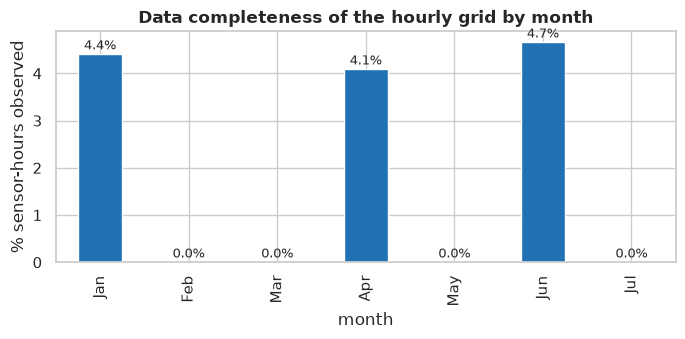

In [11]:
# completeness per month (share of sensor-hours with a valid PM2.5 value)
comp = hourly.assign(month=hourly.datetime.dt.month_name().str[:3]).groupby("month", sort=False)["is_observed"].mean().mul(100).round(2)
fig, ax = plt.subplots(figsize=(8, 3))
comp.plot.bar(ax=ax, color="#2171b5"); ax.set_ylabel("% sensor-hours observed"); ax.set_title("Data completeness of the hourly grid by month")
for i, v in enumerate(comp): ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)
savefig(fig, "02_completeness_by_month"); plt.show()

### 2.7 Gap-aware imputation
1. **Short gaps (≤ 3 consecutive hours)** inside a sensor's record → time-linear interpolation (PM2.5, PM10, temperature, humidity). `limit_area="inside"` guarantees we never extrapolate past the edges of an observation window.
2. **Long gaps** stay `NaN`; those hours are *not* used as training targets.
3. **Temperature / humidity** still missing at an hour where PM2.5 is observed → inverse-distance-weighted mean of the 3 nearest sensors (≤ 50 km) reporting at the same hour; then the sensor's own hour-of-day median; then the network median for that hour. A `met_imputed` flag records which rows were filled.

In [12]:
with stage("2.7 imputation"):
    hourly = hourly.sort_values(["device_name", "datetime"]).reset_index(drop=True)
    MAX_GAP = 3
    filled_counts = {}
    for col in ["pm2_5", "pm10", "temperature", "humidity"]:
        before = hourly[col].isna().sum()
        hourly[col] = (hourly.groupby("device_name", group_keys=False)[col]
                             .apply(lambda s: s.interpolate(method="linear", limit=MAX_GAP, limit_area="inside")))
        filled_counts[col] = int(before - hourly[col].isna().sum())
    hourly["is_observed"] = hourly["pm2_5"].notna().astype("int8")
    print("Values filled by short-gap interpolation:", filled_counts)

    # spatial IDW for temp / humidity at observed hours
    def haversine_km(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
        a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
        return 6371 * 2 * np.arcsin(np.sqrt(a))

    obs = hourly[hourly.is_observed == 1]
    hourly["met_imputed"] = False
    for col in ["temperature", "humidity"]:
        need = obs[obs[col].isna()]
        fills = {}
        for ts, grp in need.groupby("datetime"):
            donors = obs[(obs.datetime == ts) & obs[col].notna()]
            if donors.empty:
                continue
            for idx, r in grp.iterrows():
                d = haversine_km(r.latitude, r.longitude, donors.latitude.values, donors.longitude.values)
                order = np.argsort(d)[:3]
                keep = order[d[order] <= 50]
                if len(keep):
                    w = 1 / np.maximum(d[keep], 0.5) ** 2
                    fills[idx] = np.average(donors[col].values[keep], weights=w)
        s = pd.Series(fills, dtype=float)
        hourly.loc[s.index, col] = s.values
        hourly.loc[s.index, "met_imputed"] = True
        # fallbacks
        hourly["_hour"] = hourly.datetime.dt.hour
        miss = (hourly.is_observed == 1) & hourly[col].isna()
        dev_hour_med = hourly.groupby(["device_name", "_hour"])[col].transform("median")
        hourly.loc[miss, col] = dev_hour_med[miss]
        miss2 = (hourly.is_observed == 1) & hourly[col].isna()
        net_ts_med = hourly.groupby("datetime")[col].transform("median")
        hourly.loc[miss2, col] = net_ts_med[miss2]
        hourly.loc[miss | miss2, "met_imputed"] = True
        print(f"{col}: IDW-filled {len(s):,} | sensor-hour median {int(miss.sum() - miss2.sum()):,} | network median {int(miss2.sum()):,}")
    hourly = hourly.drop(columns="_hour")

    # final dtype enforcement
    hourly = hourly.astype({"device_name": "string", "site_name": "string", "network": "category",
                            "latitude": "float64", "longitude": "float64", "temperature": "float64",
                            "humidity": "float64", "pm2_5": "float64", "pm10": "float64",
                            "is_observed": "int8", "coords_imputed": bool, "met_imputed": bool})
    hourly["datetime"] = pd.to_datetime(hourly["datetime"])
    hourly.to_parquet(PROC_DIR / "hourly_grid_clean.parquet", index=False)

obs = hourly[hourly.is_observed == 1].copy()
print("\nRemaining nulls on observed rows:\n", obs[["temperature", "humidity", "pm2_5"]].isna().sum().to_string())
hourly.dtypes

[03:26:38] START  2.7 imputation


Values filled by short-gap interpolation: {'pm2_5': 1976, 'pm10': 2026, 'temperature': 1731, 'humidity': 1773}


temperature: IDW-filled 3,661 | sensor-hour median 460 | network median 0


humidity: IDW-filled 3,807 | sensor-hour median 508 | network median 0


[03:26:42] END    2.7 imputation  (4.5s)



Remaining nulls on observed rows:
 temperature    0
humidity       0
pm2_5          0


device_name                     string
datetime                datetime64[us]
temperature                    float64
humidity                       float64
pm2_5                          float64
pm10                           float64
pm25_outlier_iqr                  bool
pm25_outlier_extreme              bool
site_name                       string
network                       category
latitude                       float64
longitude                      float64
coords_imputed                    bool
is_observed                       int8
met_imputed                       bool
dtype: object

### 2.8 Feature selection — which fields actually enter the model?

| Field | Use? | Reasoning |
|---|---|---|
| `pm2_5_calibrated_value` | **Target** (as Z-score) | the quantity to predict |
| `temperature`, `humidity` | **Yes** | physically drive PM2.5 (boundary-layer height, hygroscopic growth — brief §2) |
| `datetime` → hour of day (sin/cos) | **Yes** | strong diurnal cycle: morning/evening traffic + cooking + night-time inversions |
| `datetime` → peak-dry-season flag | **Yes** | Dec–Feb is Uganda's main dry, dusty, burning season. The data confirm it: daily means are ≈ 45–55 µg/m³ in January vs ≈ 21–28 µg/m³ in April and June (table in 2.9). Jan = 1; Apr, Jun **and Aug** = 0 |
| `latitude`, `longitude` | **Yes** | spatial pattern: city centre vs peri-urban vs upcountry towns |
| `device_name` | **Yes, encoded** | smoothed, *season-adjusted* target encoding — each site's typical deviation from the network mean in the same period (roadside / market sites positive, suburbs negative). Season-adjusting matters because some sensors were online only in January (dirty) or only from April (clean) |
| `network` | **Yes** (binary) | AirQo vs AirGradient hardware may have systematic offsets |
| `pm10_calibrated_value` | **No** | co-measured by the same sensor at the same time → leakage; unavailable in a real forecast; and PM10 is driven by mechanical dust, not temp/RH (brief §2) |
| `site_name`, `site_id`, `frequency`, `sample_rate`, `network_note` | **No** | identifiers / constant / mostly empty — no predictive signal beyond `device_name` |
| day-of-week | **No** | only Mon–Fri are present (7 days total), so a weekday effect cannot be learned or validated |

### 2.9 Why a *peak* dry-season flag? (data check)

In [13]:
day_means = obs.groupby(obs.datetime.dt.date).agg(mean_pm25=("pm2_5", "mean"), median_pm25=("pm2_5", "median"),
                                                  mean_temp=("temperature", "mean"), mean_rh=("humidity", "mean"), n=("pm2_5", "size")).round(1)
day_means

,mean_pm25,median_pm25,mean_temp,mean_rh,n
datetime,,,,,
2026-01-01,54.7,55.8,24.4,71.3,2352
2026-01-02,43.6,37.2,24.9,75.1,2722
2026-01-03,46.4,44.2,20.9,88.4,619
2026-04-01,20.7,14.4,24.2,79.7,2253
2026-04-02,26.6,17.4,24.4,80.0,2677
2026-04-03,34.0,27.0,22.2,85.3,343
2026-06-01,24.5,16.9,24.3,78.9,2199
2026-06-02,23.7,16.3,23.1,81.9,2520
2026-06-03,28.5,24.3,20.4,89.7,563


January (peak dry season) is roughly **twice as polluted** as April (long rains) and early June. June therefore behaves like the non-peak months, so the season feature is `is_peak_dry_season` (Dec–Feb = 1). August — the forecast month — falls in the milder Jun–Aug dry spell and is coded 0, i.e. it is expected to resemble June. (Risk: if August turns out dustier than June, the model will under-predict; Evidently target-drift monitoring on real August data would reveal this.)

## 3. Exploratory data analysis — 5 Kampala sensors

In [14]:
KAMPALA_BOX = dict(lat=(0.22, 0.42), lon=(32.48, 32.70))
kla = obs[obs.latitude.between(*KAMPALA_BOX["lat"]) & obs.longitude.between(*KAMPALA_BOX["lon"])]
cand = (kla.groupby(["device_name", "site_name"]).agg(n_obs=("pm2_5", "size"), mean_pm25=("pm2_5", "mean"),
                                                      has_met=("met_imputed", lambda s: 1 - s.mean()))
           .reset_index().sort_values(["n_obs", "has_met"], ascending=False))
# prefer sensors with their own temp/RH and distinct sites
cand = cand[cand.has_met > 0.9].drop_duplicates("site_name")
EDA_SENSORS = cand.head(5).device_name.tolist()
EDA_NAMES = dict(zip(cand.device_name, cand.site_name))
print("Kampala-area sensors available:", kla.device_name.nunique())
cand.head(5)

Kampala-area sensors available: 95


,device_name,site_name,n_obs,mean_pm25,has_met
56,aq_58,"Nansana east ward, Wakiso",153,27.404182,1.0
60,aq_66,"Nakasero II, Kampala 66",153,37.139807,1.0
71,aq_g507,"Lower Nsooba, Kawempe",153,40.446190,1.0
83,aq_g5_37,"Civic Centre, Kampala Central",153,51.146787,1.0
4,ag_588c81267534,Salama Road,150,73.050782,1.0


In [15]:
eda = obs[obs.device_name.isin(EDA_SENSORS)].copy()
eda["label"] = eda.device_name.map(lambda d: f"{EDA_NAMES[d][:28]}")
eda["aqi"] = aqi_category(eda.pm2_5)
eda[["pm2_5", "temperature", "humidity"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
pm2_5,762.0,45.73,39.91,6.39,18.56,31.69,59.02,290.98
temperature,762.0,24.27,3.41,17.99,21.49,23.76,26.69,35.40
humidity,762.0,79.99,12.71,41.82,71.95,82.11,89.93,98.87


### 3.1 Distribution plots

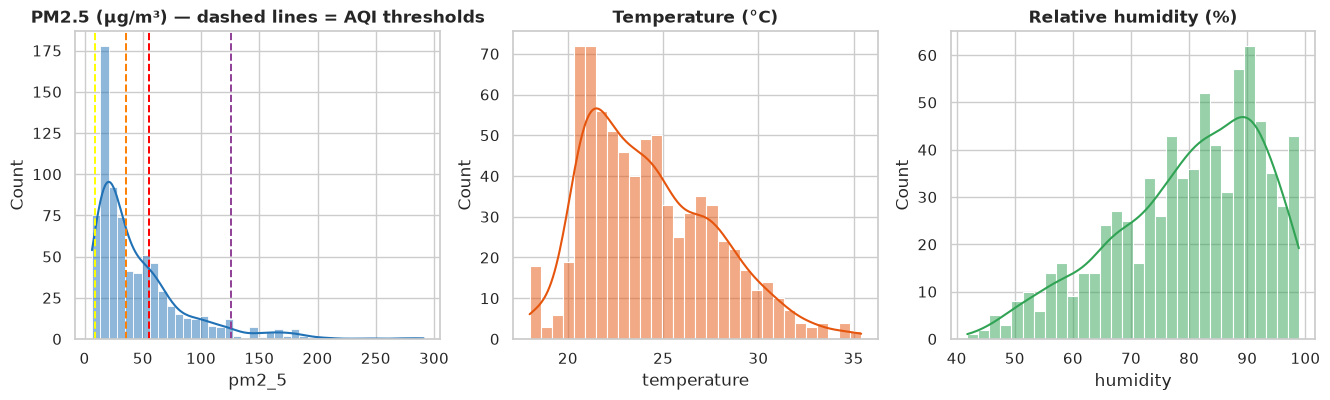

PM2.5 skewness = 2.09  (>1 = strongly right-skewed: many moderate hours, few very high spikes)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(eda, x="pm2_5", kde=True, ax=axes[0], color="#2171b5", bins=40)
for t, c in zip(AQI_BINS[1:5], AQI_COLORS[1:5]): axes[0].axvline(t, color=c, ls="--", lw=1.4)
axes[0].set_title("PM2.5 (µg/m³) — dashed lines = AQI thresholds")
sns.histplot(eda, x="temperature", kde=True, ax=axes[1], color="#e6550d", bins=30); axes[1].set_title("Temperature (°C)")
sns.histplot(eda, x="humidity", kde=True, ax=axes[2], color="#31a354", bins=30); axes[2].set_title("Relative humidity (%)")
savefig(fig, "03_distributions"); plt.show()
print(f"PM2.5 skewness = {eda.pm2_5.skew():.2f}  (>1 = strongly right-skewed: many moderate hours, few very high spikes)")

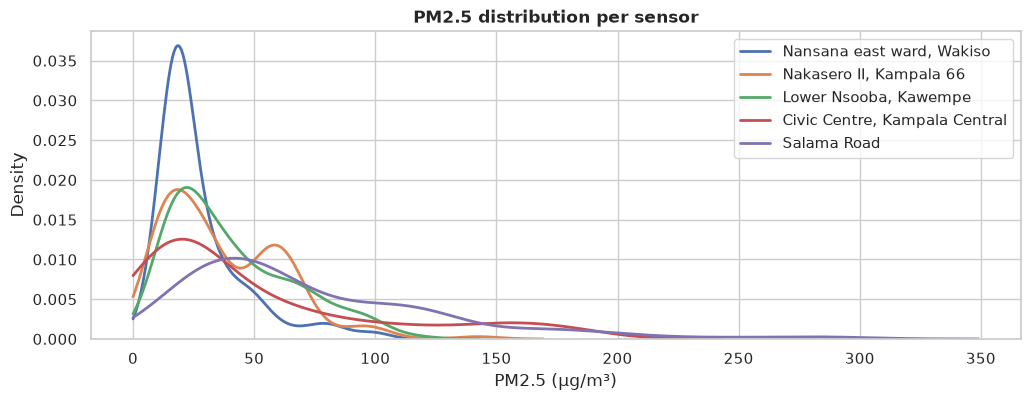

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))
for d in EDA_SENSORS:
    sns.kdeplot(eda[eda.device_name == d].pm2_5, ax=ax, label=EDA_NAMES[d][:30], lw=2, clip=(0, None))
ax.set_xlabel("PM2.5 (µg/m³)"); ax.set_title("PM2.5 distribution per sensor"); ax.legend()
savefig(fig, "03b_distribution_per_sensor"); plt.show()

### 3.2 Box plots & outlier tracking

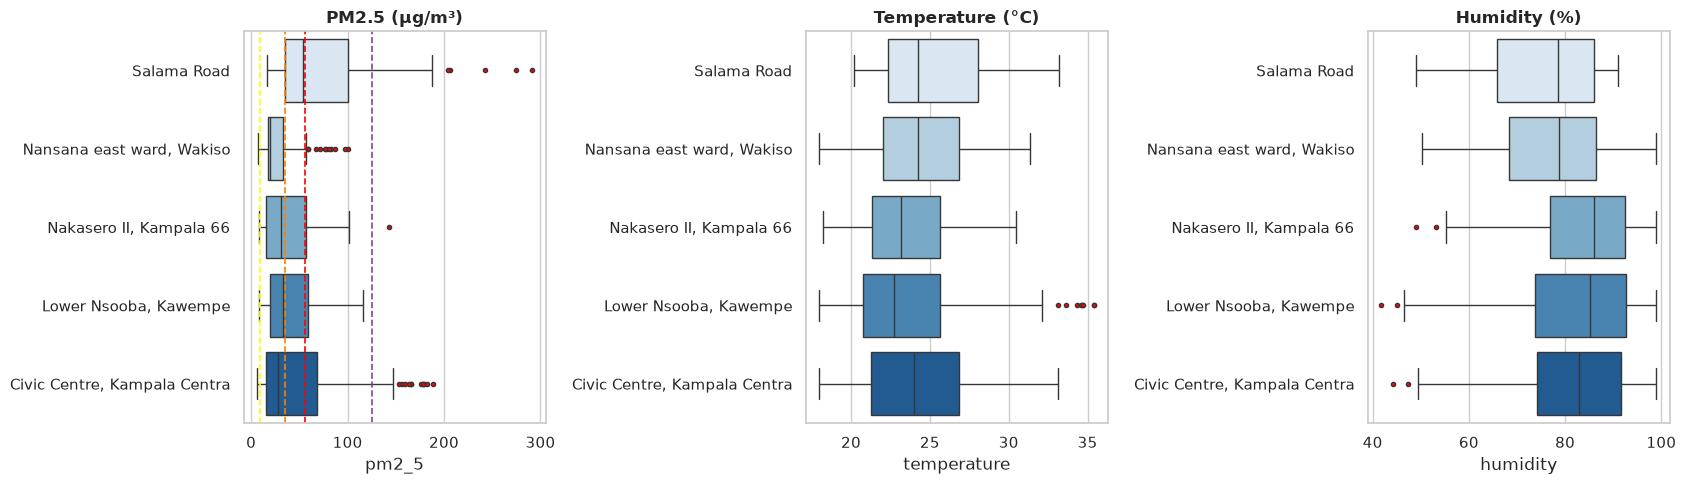

,n,median,max,iqr_outliers,extreme_outliers,treatment
label,,,,,,
"Civic Centre, Kampala Centra",153,27.6,188.2,17,0,flagged & kept
"Lower Nsooba, Kawempe",153,33.5,115.9,1,0,flagged & kept
"Nakasero II, Kampala 66",153,30.6,142.4,1,0,flagged & kept
"Nansana east ward, Wakiso",153,19.9,100.8,11,4,flagged & kept
Salama Road,150,53.9,291.0,5,0,flagged & kept


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col, title in zip(axes, ["pm2_5", "temperature", "humidity"], ["PM2.5 (µg/m³)", "Temperature (°C)", "Humidity (%)"]):
    sns.boxplot(eda, y="label", x=col, ax=ax, palette="Blues", fliersize=3, flierprops=dict(marker="o", markerfacecolor="red"))
    ax.set_title(title); ax.set_ylabel("")
    if col == "pm2_5":
        for t, c in zip(AQI_BINS[1:5], AQI_COLORS[1:5]): ax.axvline(t, color=c, ls="--", lw=1.2)
plt.tight_layout(); savefig(fig, "03c_boxplots"); plt.show()

eda_outliers = (eda.groupby("label").agg(n=("pm2_5", "size"), median=("pm2_5", "median"), max=("pm2_5", "max"),
                                         iqr_outliers=("pm25_outlier_iqr", "sum"), extreme_outliers=("pm25_outlier_extreme", "sum"))
                   .round(1))
eda_outliers["treatment"] = "flagged & kept"
eda_outliers

**Outlier treatment.** Red points are hours beyond 1.5×IQR of that sensor. They coincide with morning/evening rush hours and night-time inversions, i.e. *real* pollution episodes, so they are **kept** (with `pm25_outlier_iqr` / `pm25_outlier_extreme` flags) — dropping them would teach the model that Kampala never has unhealthy hours. Only physically impossible values (> 500 µg/m³) were removed (Section 2.5). Tree-based models are robust to such spikes; for the linear/SVR/KNN models the features are standardised and the target is Z-scored.

### 3.3 Time-series plots with AQI bands
The three observation windows are plotted side by side (the months in between have no data).

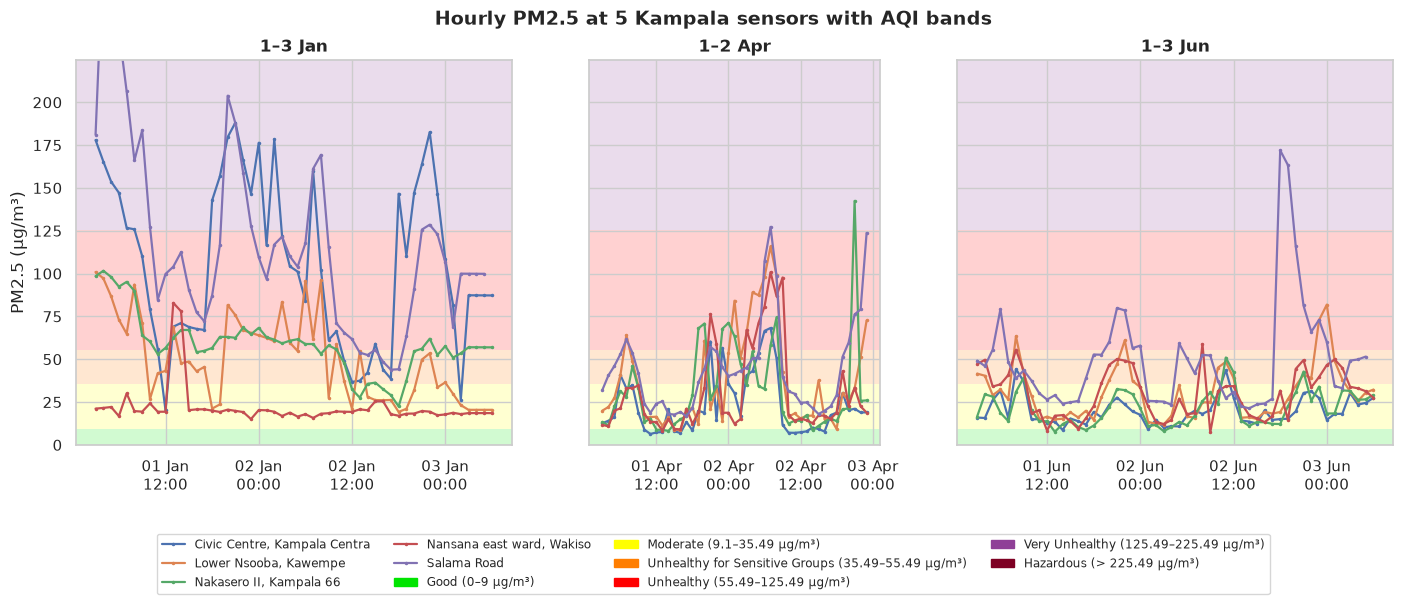

In [19]:
WINDOWS = [("2026-01-01", "2026-01-03 23:00", "1–3 Jan"), ("2026-04-01", "2026-04-02 23:00", "1–2 Apr"), ("2026-06-01", "2026-06-03 23:00", "1–3 Jun")]
def windowed_ts(data, value_col, label_col, title, fname, ymax=None, ylabel="PM2.5 (µg/m³)"):
    ymax = ymax or float(np.nanpercentile(data[value_col], 99.5) * 1.1)
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True, gridspec_kw={"width_ratios": [3, 2, 3]})
    for ax, (s, e, name) in zip(axes, WINDOWS):
        w = data[(data.datetime >= s) & (data.datetime <= e)]
        add_aqi_bands(ax, ymax)
        for lab, g in w.groupby(label_col):
            ax.plot(g.datetime, g[value_col], lw=1.6, marker=".", ms=3, label=lab)
        ax.set_title(name)
        ax.xaxis.set_major_locator(matplotlib.dates.HourLocator(byhour=[0, 12]))
        ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%d %b\n%H:%M"))
    axes[0].set_ylabel(ylabel)
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h + aqi_legend_handles(), l + [p.get_label() for p in aqi_legend_handles()], loc="lower center",
               ncol=4, fontsize=8.5, bbox_to_anchor=(0.5, -0.2))
    fig.suptitle(title, fontsize=14, weight="bold"); savefig(fig, fname); plt.show()

windowed_ts(eda, "pm2_5", "label", "Hourly PM2.5 at 5 Kampala sensors with AQI bands", "03d_timeseries_aqi")

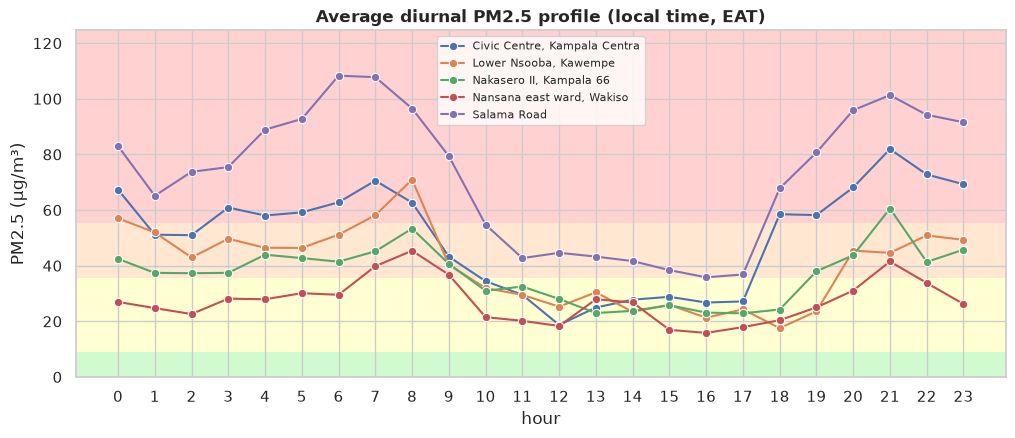

In [20]:
# Diurnal profile (local time) — explains the hour-of-day feature
diurnal = eda.assign(hour=eda.datetime.dt.hour).groupby(["hour", "label"]).pm2_5.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 4.5))
add_aqi_bands(ax, diurnal.pm2_5.max() * 1.15)
sns.lineplot(diurnal, x="hour", y="pm2_5", hue="label", marker="o", ax=ax)
ax.set_xticks(range(0, 24)); ax.set_title("Average diurnal PM2.5 profile (local time, EAT)"); ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(fontsize=8)
savefig(fig, "03e_diurnal_profile"); plt.show()

### 3.4 Calendar plots (unscaled, cleaned PM2.5, AQI colours)
Daily mean PM2.5 per sensor, January–July 2026. Grey = no data (sensor network offline / not delivered), which makes the data gaps visible at a glance.

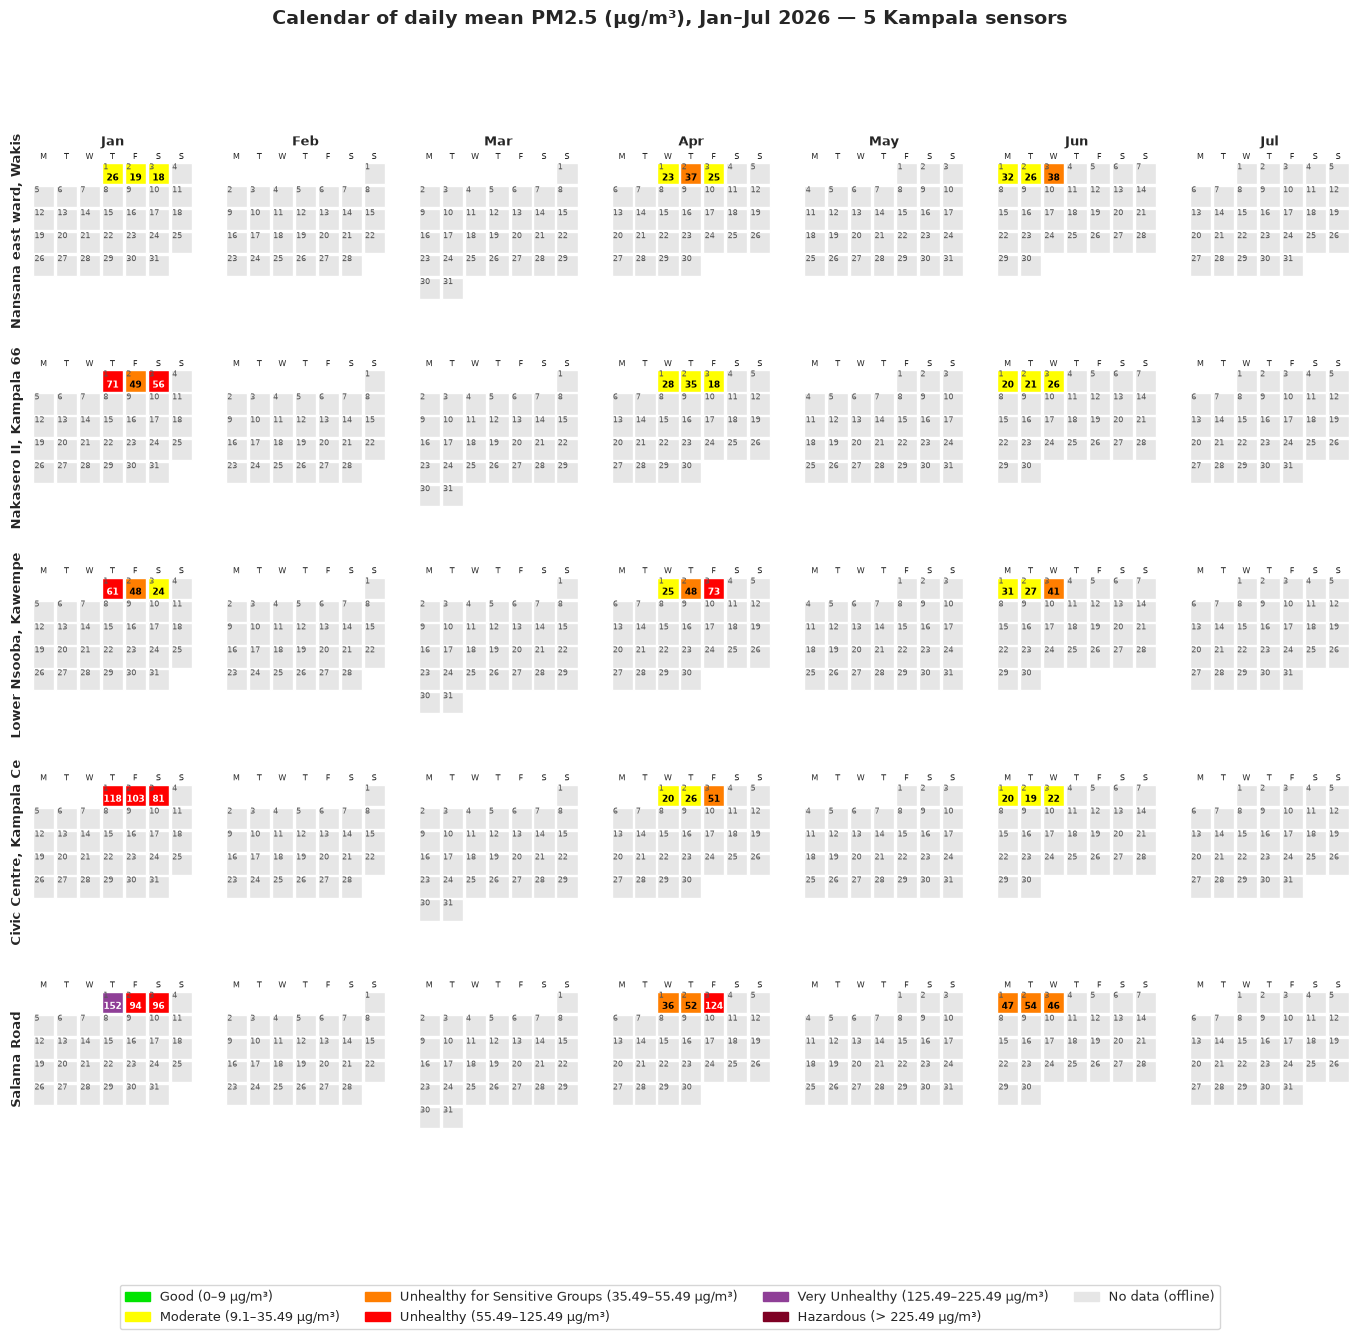

In [21]:
aqi_cmap = ListedColormap(AQI_COLORS)
aqi_norm = BoundaryNorm(AQI_BINS[:-1] + [1000], aqi_cmap.N)

def month_grid(ax, year, month, daily, title=None, annotate=True, show_wd=True):
    cal = calendar.Calendar(firstweekday=0).monthdatescalendar(year, month)
    ax.set_xlim(0, 7); ax.set_ylim(6, -0.5); ax.set_aspect("equal"); ax.axis("off")
    for r, week in enumerate(cal):
        for c, day in enumerate(week):
            if day.month != month:
                continue
            v = daily.get(pd.Timestamp(day), np.nan)
            col = "#e6e6e6" if np.isnan(v) else aqi_cmap(aqi_norm(v))
            ax.add_patch(mpatches.Rectangle((c + 0.04, r + 0.04), 0.92, 0.92, fc=col, ec="white"))
            ax.text(c + 0.1, r + 0.3, day.day, fontsize=5.5, color="#555")
            if annotate and not np.isnan(v):
                ax.text(c + 0.5, r + 0.68, f"{v:.0f}", ha="center", va="center", fontsize=6.5, weight="bold",
                        color="white" if v > 55.49 else "black")
    if show_wd:
        for c, wd in enumerate("MTWTFSS"):
            ax.text(c + 0.5, -0.15, wd, ha="center", fontsize=6)
    if title: ax.set_title(title, fontsize=9, pad=4)

daily_eda = eda.groupby(["device_name", eda.datetime.dt.normalize()]).pm2_5.mean()
fig, axes = plt.subplots(len(EDA_SENSORS), 7, figsize=(17, 2.6 * len(EDA_SENSORS)))
for i, d in enumerate(EDA_SENSORS):
    ser = daily_eda.loc[d].to_dict()
    for j, mth in enumerate(range(1, 8)):
        month_grid(axes[i, j], 2026, mth, ser, title=calendar.month_abbr[mth] if i == 0 else None)
    axes[i, 0].text(-0.4, 3, EDA_NAMES[d][:24], rotation=90, va="center", ha="right", fontsize=9, weight="bold")
fig.legend(handles=aqi_legend_handles() + [mpatches.Patch(color="#e6e6e6", label="No data (offline)")],
           loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Calendar of daily mean PM2.5 (µg/m³), Jan–Jul 2026 — 5 Kampala sensors", fontsize=14, weight="bold")
savefig(fig, "03f_calendar_eda"); plt.show()

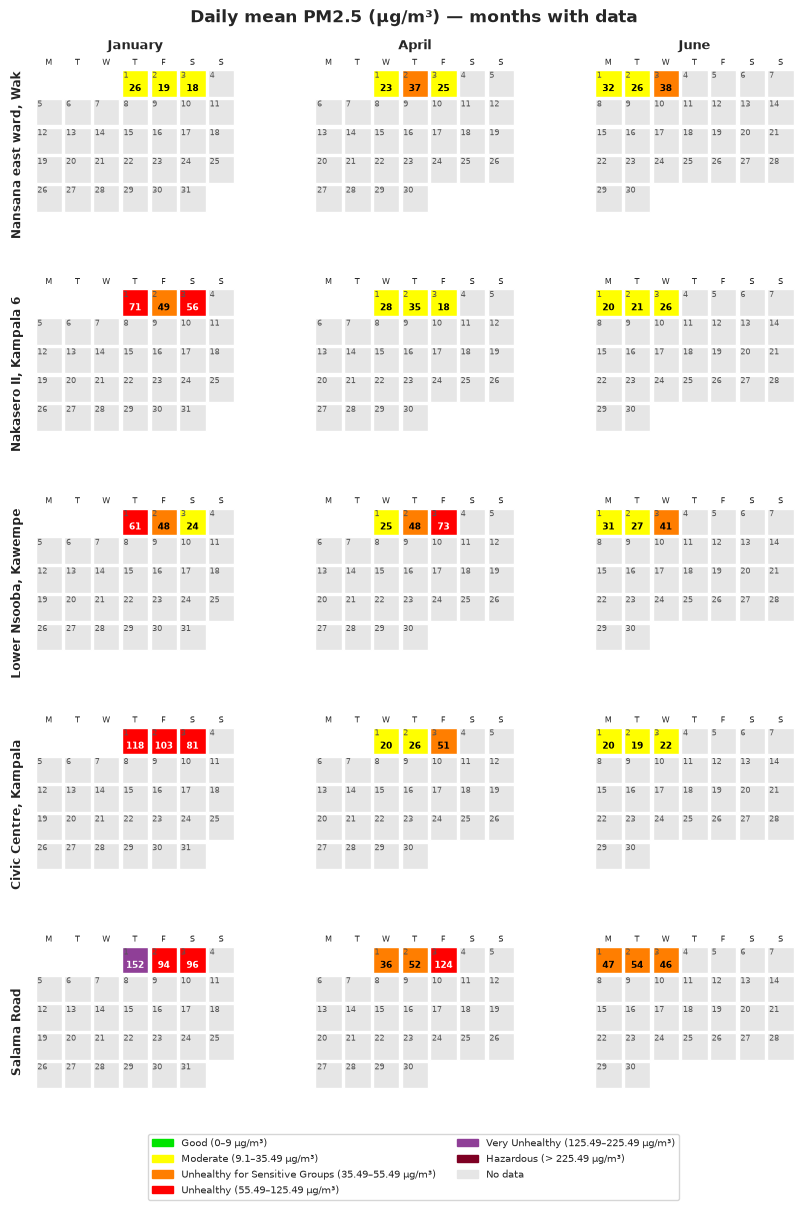

In [22]:
# compact version: only the months that contain data (Jan, Apr, Jun) — easier to read
fig, axes = plt.subplots(len(EDA_SENSORS), 3, figsize=(9, 2.3 * len(EDA_SENSORS)))
for i, d in enumerate(EDA_SENSORS):
    ser = daily_eda.loc[d].to_dict()
    for j, mth in enumerate([1, 4, 6]):
        month_grid(axes[i, j], 2026, mth, ser, title=calendar.month_name[mth] if i == 0 else None)
    axes[i, 0].text(-0.4, 3, EDA_NAMES[d][:22], rotation=90, va="center", ha="right", fontsize=8.5, weight="bold")
fig.legend(handles=aqi_legend_handles() + [mpatches.Patch(color="#e6e6e6", label="No data")], loc="lower center", ncol=2,
           fontsize=7.5, bbox_to_anchor=(0.5, -0.06))
fig.suptitle("Daily mean PM2.5 (µg/m³) — months with data", fontsize=12, weight="bold")
plt.tight_layout(); savefig(fig, "03f2_calendar_observed_months"); plt.show()

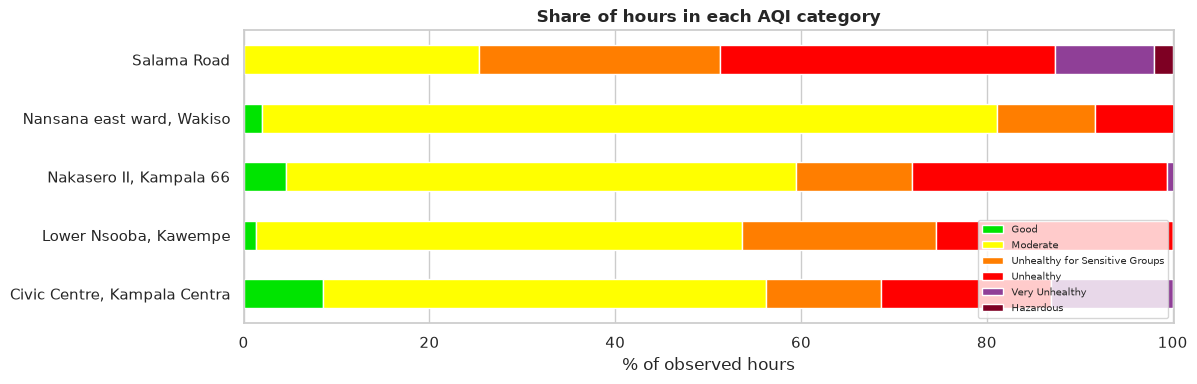

aqi,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,Hazardous
label,,,,,,
"Civic Centre, Kampala Centra",8.5,47.7,12.4,18.3,13.1,0.0
"Lower Nsooba, Kawempe",1.3,52.3,20.9,25.5,0.0,0.0
"Nakasero II, Kampala 66",4.6,54.9,12.4,27.5,0.7,0.0
"Nansana east ward, Wakiso",2.0,79.1,10.5,8.5,0.0,0.0
Salama Road,0.0,25.3,26.0,36.0,10.7,2.0


In [23]:
cat_share = (eda.groupby("label").aqi.value_counts(normalize=True).mul(100).round(1).unstack().reindex(columns=AQI_LABELS).fillna(0))
fig, ax = plt.subplots(figsize=(12, 3.8))
cat_share.plot.barh(stacked=True, color=AQI_COLORS, ax=ax, edgecolor="white")
ax.set_xlabel("% of observed hours"); ax.set_title("Share of hours in each AQI category"); ax.legend(fontsize=7.5, loc="lower right")
ax.set_ylabel("")
savefig(fig, "03g_aqi_share"); plt.show()
cat_share

### 3.5 Z-score transformation of PM2.5 (all sensors)
$$z = \frac{x - \mu}{\sigma}$$
We compute two versions:
* **Global Z** (one μ, σ for the whole network) — used as the **model target** because a single pair of constants makes the inverse transform $x = z\sigma + \mu$ trivial and keeps differences *between* sensors (a polluted market vs a clean suburb) in the target.
* **Per-sensor Z** (each sensor's own μ, σ) — used for interpretation: it tells how unusual an hour is *for that location*.

In [24]:
MU_ALL, SD_ALL = obs.pm2_5.mean(), obs.pm2_5.std()
obs["pm25_z_global"] = (obs.pm2_5 - MU_ALL) / SD_ALL
obs["pm25_z_sensor"] = obs.groupby("device_name").pm2_5.transform(lambda s: (s - s.mean()) / s.std())
print(f"Global mean μ = {MU_ALL:.2f} µg/m³, std σ = {SD_ALL:.2f} µg/m³")
z_thr = pd.DataFrame({"AQI threshold (µg/m³)": AQI_BINS[1:6], "category above": AQI_LABELS[1:6]})
z_thr["equivalent global Z"] = ((z_thr["AQI threshold (µg/m³)"] - MU_ALL) / SD_ALL).round(2)
display(z_thr)
print("Share of observed hours with |z| > 2:", f"{(obs.pm25_z_global.abs() > 2).mean()*100:.1f}%",
      "| > 3:", f"{(obs.pm25_z_global.abs() > 3).mean()*100:.1f}%")

Global mean μ = 32.96 µg/m³, std σ = 27.73 µg/m³


,AQI threshold (µg/m³),category above,equivalent global Z
0,9.00,Moderate,-0.86
1,35.49,Unhealthy for Sensitive Groups,0.09
2,55.49,Unhealthy,0.81
3,125.49,Very Unhealthy,3.34
4,225.49,Hazardous,6.94


Share of observed hours with |z| > 2: 4.7% | > 3: 1.5%


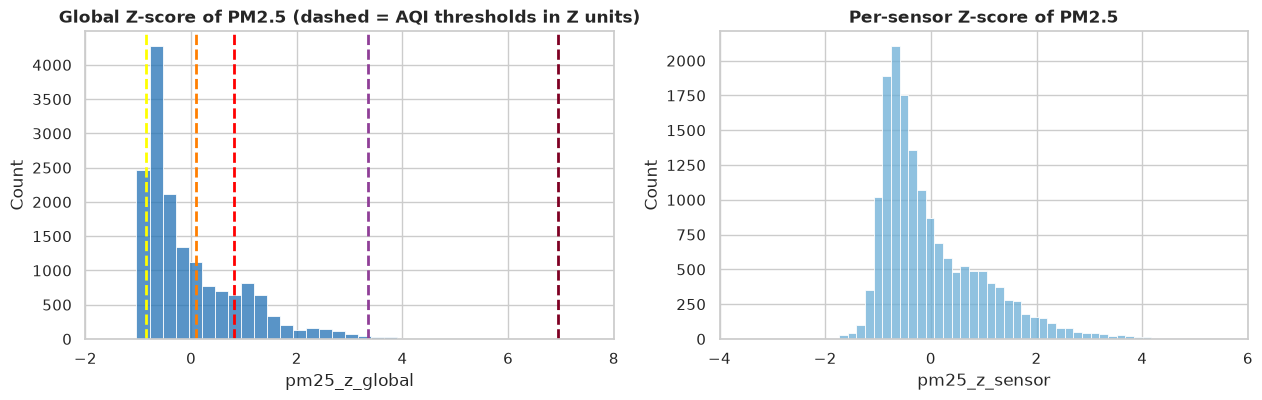

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(obs.pm25_z_global, bins=60, ax=axes[0], color="#2171b5")
for z, c in zip(z_thr["equivalent global Z"], AQI_COLORS[1:6]):
    if z < 8: axes[0].axvline(z, color=c, lw=2, ls="--")
axes[0].set_title("Global Z-score of PM2.5 (dashed = AQI thresholds in Z units)"); axes[0].set_xlim(-2, 8)
sns.histplot(obs.pm25_z_sensor, bins=60, ax=axes[1], color="#6baed6")
axes[1].set_title("Per-sensor Z-score of PM2.5"); axes[1].set_xlim(-4, 6)
savefig(fig, "03h_zscore"); plt.show()

**Interpreting the Z-scores.**
* `z = 0` is the network-average hour (≈ μ µg/m³). `z = +1` is one standard deviation dirtier than average; `z = −1` cleaner.
* Because PM2.5 cannot go below 0, the lowest possible Z is about −μ/σ (≈ −1), while spikes reach +5 to +10: **Z-scoring re-centres and re-scales but does not remove skew** (observed range ≈ −1.0 to +13.8) — the distribution is still long-tailed.
* The table above translates AQI thresholds into Z units: anything above the "Unhealthy for Sensitive Groups" threshold already corresponds to a positive Z, so "above-average" in Kampala is already unhealthy by WHO standards.
* Per-sensor Z answers a different question: a sensor at `z_sensor = +3` is having an exceptional hour *for that site* — useful for anomaly alerts (e.g. a fire nearby) even where absolute levels are moderate.
* Hours with |z| > 3 are statistical outliers in the Gaussian sense; we flagged rather than removed them (Section 3.2).

### 3.6 Correlation between temperature, humidity and PM2.5 (5 Kampala sensors)

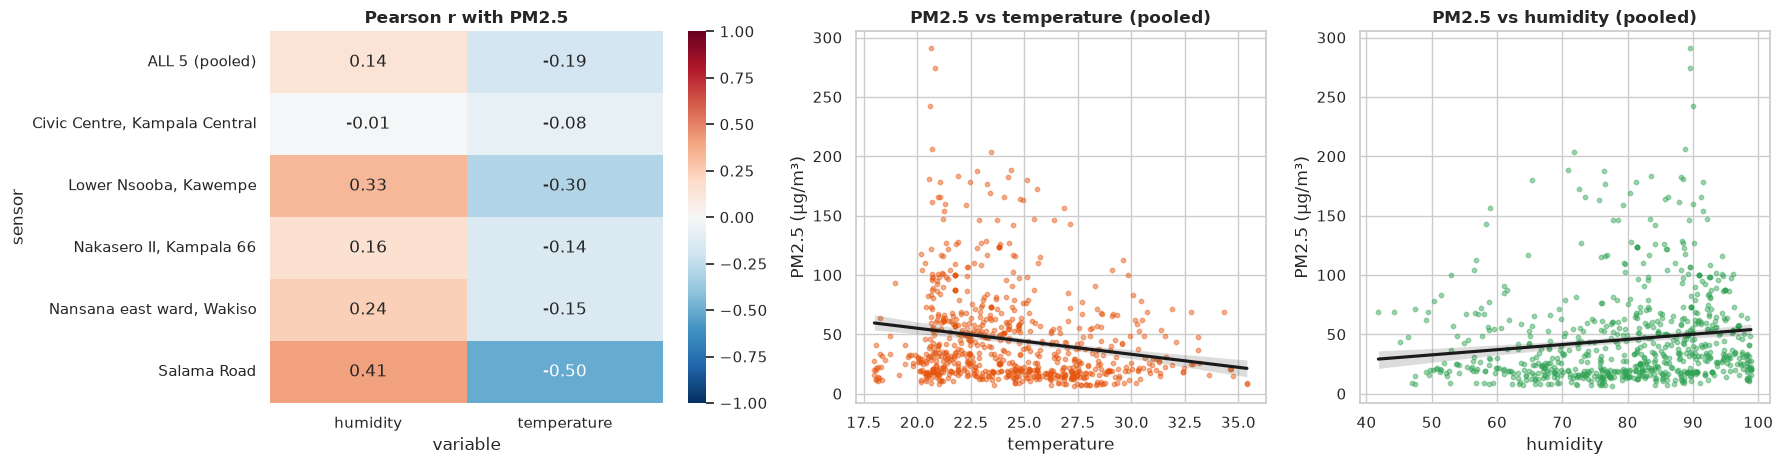

,sensor,variable,pearson_r,spearman_rho,n
0,"Nansana east ward, Wakiso",temperature,-0.154,-0.198,153
1,"Nansana east ward, Wakiso",humidity,0.238,0.254,153
2,"Nakasero II, Kampala 66",temperature,-0.141,-0.144,153
3,"Nakasero II, Kampala 66",humidity,0.157,0.254,153
4,"Lower Nsooba, Kawempe",temperature,-0.304,-0.306,153
5,"Lower Nsooba, Kawempe",humidity,0.334,0.366,153
6,"Civic Centre, Kampala Central",temperature,-0.082,-0.096,153
7,"Civic Centre, Kampala Central",humidity,-0.014,0.061,153
8,Salama Road,temperature,-0.502,-0.544,150
9,Salama Road,humidity,0.413,0.474,150


In [26]:
rows = []
for d in EDA_SENSORS:
    g = eda[(eda.device_name == d) & (~eda.met_imputed)]
    for v in ["temperature", "humidity"]:
        rows.append({"sensor": EDA_NAMES[d][:30], "variable": v,
                     "pearson_r": g[v].corr(g.pm2_5), "spearman_rho": g[v].corr(g.pm2_5, method="spearman"), "n": len(g)})
g = eda[~eda.met_imputed]
for v in ["temperature", "humidity"]:
    rows.append({"sensor": "ALL 5 (pooled)", "variable": v, "pearson_r": g[v].corr(g.pm2_5),
                 "spearman_rho": g[v].corr(g.pm2_5, method="spearman"), "n": len(g)})
CORR = pd.DataFrame(rows).round(3)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), gridspec_kw={"width_ratios": [1.2, 1, 1]})
sns.heatmap(CORR.pivot(index="sensor", columns="variable", values="pearson_r"), annot=True, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[0], fmt=".2f"); axes[0].set_title("Pearson r with PM2.5")
for ax, v, c in zip(axes[1:], ["temperature", "humidity"], ["#e6550d", "#31a354"]):
    sns.regplot(g, x=v, y="pm2_5", ax=ax, scatter_kws=dict(s=10, alpha=0.45, color=c), line_kws=dict(color="k"))
    ax.set_title(f"PM2.5 vs {v} (pooled)"); ax.set_ylabel("PM2.5 (µg/m³)")
plt.tight_layout(); savefig(fig, "03i_correlation"); plt.show()
CORR

**Interpretation.** Temperature is **negatively** correlated with PM2.5 and humidity **positively** at most sensors. This matches the physics in the brief: cool, humid early mornings and nights have a shallow boundary layer (temperature inversion), which traps emissions from cooking and traffic near the ground; in the warm afternoon the boundary layer deepens and pollutants dilute. Correlations are weak to moderate (|r| from ≈ 0.1 at Civic Centre — a traffic-dominated site where emissions swamp the weather signal — up to ≈ 0.5 at Salama Road), so temperature and humidity are useful but not sufficient on their own — location and time of day carry much of the signal. Spearman ρ (rank-based) is reported alongside Pearson r because PM2.5 is skewed and the relationship is monotonic but not perfectly linear.

## 4. Machine-learning models
### 4.1 Features, target and a leakage-free chronological split

In [27]:
def peak_dry(ts):
    """Main dry season in Uganda (Dec–Feb). Jan = 1; Apr, Jun, Aug = 0."""
    return ts.dt.month.isin([12, 1, 2]).astype(int)

def build_features(frame, dev_enc, global_enc):
    X = pd.DataFrame(index=frame.index)
    h = frame.datetime.dt.hour
    X["hour_sin"] = np.sin(2 * np.pi * h / 24)
    X["hour_cos"] = np.cos(2 * np.pi * h / 24)
    X["is_peak_dry_season"] = peak_dry(frame.datetime)
    X["latitude"] = frame.latitude.values
    X["longitude"] = frame.longitude.values
    X["temperature"] = frame.temperature.values
    X["humidity"] = frame.humidity.values
    X["is_airgradient"] = (frame.network.astype(str) == "airgradient").astype(int)
    X["device_level"] = frame.device_name.map(dev_enc).fillna(global_enc).astype(float).values
    return X

FEATURES = ["hour_sin", "hour_cos", "is_peak_dry_season", "latitude", "longitude", "temperature", "humidity", "is_airgradient", "device_level"]

data = obs.sort_values("datetime").reset_index(drop=True)
train_df = data[data.datetime < TEST_START].copy()
test_df = data[data.datetime >= TEST_START].copy()

# target scaler fitted on TRAIN only (no leakage); EDA Z above used all data purely for description
MU, SIGMA = train_df.pm2_5.mean(), train_df.pm2_5.std()
train_df["y"] = (train_df.pm2_5 - MU) / SIGMA
test_df["y"] = (test_df.pm2_5 - MU) / SIGMA

# smoothed, season-adjusted target encoding of each device's typical level (train only):
# deviation of the device from the network mean of the same observation window, shrunk toward 0 for devices with few rows
SMOOTH_M = 10
train_df["_dev"] = train_df.y - train_df.groupby(train_df.datetime.dt.month).y.transform("mean")
stats_ = train_df.groupby("device_name")["_dev"].agg(["mean", "count"])
DEVICE_ENC = ((stats_["mean"] * stats_["count"]) / (stats_["count"] + SMOOTH_M)).to_dict()
GLOBAL_ENC = 0.0
# CV groups = calendar day (blocked cross-validation)
GROUPS = train_df.datetime.dt.date.astype(str).values

X_train, y_train = build_features(train_df, DEVICE_ENC, GLOBAL_ENC), train_df.y.values
X_test, y_test = build_features(test_df, DEVICE_ENC, GLOBAL_ENC), test_df.y.values
print(f"Target scaler (train): μ = {MU:.2f} µg/m³, σ = {SIGMA:.2f} µg/m³")
print(f"Train: {len(X_train):,} rows ({train_df.datetime.min()} → {train_df.datetime.max()})")
print(f"Test : {len(X_test):,} rows ({test_df.datetime.min()} → {test_df.datetime.max()})")
logger.info(f"train rows={len(X_train)}, test rows={len(X_test)}, MU={MU:.3f}, SIGMA={SIGMA:.3f}")
X_train.describe().T.round(3)

Target scaler (train): μ = 34.22 µg/m³, σ = 28.36 µg/m³
Train: 13,780 rows (2026-01-01 03:00:00 → 2026-06-02 05:00:00)
Test : 2,468 rows (2026-06-02 06:00:00 → 2026-06-03 06:00:00)
[03:26:53] train rows=13780, test rows=2468, MU=34.222, SIGMA=28.364


,count,mean,std,min,25%,50%,75%,max
hour_sin,13780.0,0.001,0.709,-1.000,-0.707,0.000,0.707,1.000
hour_cos,13780.0,0.003,0.705,-1.000,-0.707,0.000,0.707,1.000
is_peak_dry_season,13780.0,0.413,0.492,0.000,0.000,0.000,1.000,1.000
latitude,13780.0,0.315,0.738,-1.273,0.298,0.332,0.398,2.826
longitude,13780.0,32.118,0.939,29.939,32.042,32.573,32.612,33.235
temperature,13780.0,24.062,4.078,12.700,21.166,23.673,26.855,44.510
humidity,13780.0,78.128,13.953,26.530,69.543,80.364,89.116,99.000
is_airgradient,13780.0,0.033,0.179,0.000,0.000,0.000,0.000,1.000
device_level,13780.0,-0.002,0.396,-0.972,-0.239,-0.023,0.168,1.467


**Why a chronological split?** A random split would put neighbouring hours of the same sensor in both train and test; because PM2.5 is strongly autocorrelated, the model would look much better than it really is. We train on the past (Jan, Apr and the first day of June) and test on the **last full 24 hours** observed (2 Jun 06:00 → 3 Jun 06:00), which mimics real forecasting, covers a whole diurnal cycle, and is in the same season as the August forecast.

**Why blocked (leave-days-out) cross-validation for tuning?** Hyper-parameters are tuned with `GroupKFold` where each group is a **calendar day** (Roberts et al., 2017). Whole days are held out, so hours from the same day never sit on both sides of a fold. A plain `TimeSeriesSplit` was tried first and rejected: its early folds train on January only and validate on April, so the model never sees a wet-season hour in training — tuning then favours over-smoothed models. The test set is never used during tuning.

### 4.2 Evaluation metrics — and why
* **RMSE (primary, used for tuning & model selection)** — squares errors before averaging, so it punishes large misses heavily. For air quality, under-predicting a pollution spike is the costly error (people are not warned), so we want a metric that penalises big misses. In Z units, RMSE = 0.5 means a typical error of half a standard deviation; multiplied by σ it is in µg/m³.
* **MAE** — average absolute error, robust to outliers and easy to explain ("on average we are off by X µg/m³"). If RMSE ≫ MAE, errors are dominated by a few large misses.
* **R²** — share of the variance in PM2.5 the model explains, versus always predicting the mean (R² = 0). Negative R² = worse than the mean.
* **AQI-category accuracy** — after inverse transform, the % of hours placed in the correct AQI band — the metric the public/NEMA actually experiences.
* **When another metric is better:** MAPE is *not* used on Z-scores (values near 0 make it explode) and is unreliable even in µg/m³ at very low concentrations; if the use-case were a public health alert (e.g. "will it exceed 55 µg/m³?"), recall/precision on an exceedance classification would be more appropriate; if large and small errors mattered equally, MAE would be the primary metric.

In [28]:
def evaluate(name, y_true_z, y_pred_z, split):
    true_ug, pred_ug = y_true_z * SIGMA + MU, np.clip(y_pred_z * SIGMA + MU, 0, None)
    return {"model": name, "split": split,
            "RMSE_z": np.sqrt(mean_squared_error(y_true_z, y_pred_z)), "MAE_z": mean_absolute_error(y_true_z, y_pred_z),
            "R2": r2_score(y_true_z, y_pred_z),
            "RMSE_ugm3": np.sqrt(mean_squared_error(true_ug, pred_ug)), "MAE_ugm3": mean_absolute_error(true_ug, pred_ug),
            "AQI_accuracy_%": (aqi_category(true_ug).astype(str) == aqi_category(pred_ug).astype(str)).mean() * 100}

cv_days = GroupKFold(n_splits=5)
RESULTS, BEST_PARAMS, MODELS, CV_SCORES, TRAIN_TIMES = [], {}, {}, {}, {}

# Baselines (no learning) — the yardstick every model must beat
RESULTS.append(evaluate("Baseline: global mean", y_test, np.zeros_like(y_test), "test"))
RESULTS.append(evaluate("Baseline: sensor mean", y_test, X_test.device_level.values, "test"))
pd.DataFrame(RESULTS).round(3)

,model,split,RMSE_z,MAE_z,R2,RMSE_ugm3,MAE_ugm3,AQI_accuracy_%
0,Baseline: global mean,test,0.850,0.664,-0.135,24.098,18.839,72.528
1,Baseline: sensor mean,test,0.842,0.647,-0.114,23.874,18.362,48.744


### 4.3 Five tuned models
| # | Model | Hyper-parameters tuned | Why these matter |
|---|---|---|---|
| 1 | **Ridge regression** (+ optional polynomial terms) | `alpha` (L2 strength, 1e-3 → 1e3), `poly__degree` (1 or 2) | `alpha` trades variance for bias: small α ≈ ordinary least squares (can overfit with correlated features like temp & humidity), large α shrinks coefficients toward 0 (underfit). Degree 2 adds interactions (e.g. temperature × hour) — more flexible but more prone to overfit, which is why α is tuned jointly. |
| 2 | **K-Nearest Neighbours** | `n_neighbors` (3–60), `weights` (uniform/distance), `p` (1 = Manhattan, 2 = Euclidean) | k controls smoothness: small k memorises noise (high variance), large k over-smooths spikes (high bias). Distance weighting lets close neighbours dominate; the metric changes what "similar hour" means. Features are standardised because KNN is distance-based. |
| 3 | **Support Vector Regression (RBF)** | `C` (0.1–100), `gamma` (1e-3–1), `epsilon` (0.01–0.5) | `C` = penalty for errors outside the tube (high C fits spikes, risks overfitting); `gamma` = kernel width (high γ → very local, wiggly function); `epsilon` = width of the "no-penalty" tube — errors smaller than ε are ignored, so it sets the tolerance for noise. |
| 4 | **Random Forest** (bagging ensemble) | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` | More trees reduce variance (with diminishing returns, more compute). `max_depth`/`min_samples_leaf` limit how specific each tree's rules can be (overfitting control). `max_features` de-correlates trees — fewer features per split → more diverse trees → better averaging. |
| 5 | **XGBoost** (gradient-boosting ensemble) | `n_estimators`, `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, `reg_lambda` | Boosting adds trees sequentially to fix previous errors: `learning_rate` × `n_estimators` sets how far it goes (low rate + many trees = smoother, slower); `max_depth`/`min_child_weight` control tree complexity; `subsample`/`colsample_bytree` add randomness that prevents overfitting; `reg_lambda` is L2 regularisation on leaf weights. |
| 6 | **Stacking ensemble** | base learners = tuned RF, XGBoost, KNN, SVR; meta-learner `RidgeCV` (alpha tuned by internal CV) | Combines models that make *different kinds* of errors (trees vs distance vs kernel); the meta-learner learns how much to trust each one. |

In [29]:
def tune(name, estimator, param_dist, n_iter, X=X_train, y=y_train, groups=GROUPS):
    with stage(f"4. tune {name}"):
        t0 = time.perf_counter()
        search = RandomizedSearchCV(estimator, param_dist, n_iter=n_iter, cv=cv_days, scoring="neg_root_mean_squared_error",
                                    random_state=RANDOM_STATE, n_jobs=-1, refit=False)
        search.fit(X, y, groups=groups)
        best = search.best_params_
        model = estimator.set_params(**best).fit(X_train, y_train)   # refit on the FULL training set
        TRAIN_TIMES[name] = time.perf_counter() - t0
    BEST_PARAMS[name], MODELS[name] = best, model
    CV_SCORES[name] = -search.best_score_
    cvres = pd.DataFrame(search.cv_results_)
    RESULTS.append(evaluate(name, y_train, model.predict(X_train), "train"))
    RESULTS.append(evaluate(name, y_test, model.predict(X_test), "test"))
    logger.info(f"{name}: best CV RMSE_z={-search.best_score_:.4f} | params={best}")
    print(f"{name}: CV RMSE (z) = {-search.best_score_:.4f} ± {cvres.loc[search.best_index_, 'std_test_score']:.4f}")
    print("  best params:", best)
    return search

# 1. Ridge (with optional polynomial interaction terms)
ridge = Pipeline([("poly", PolynomialFeatures(include_bias=False)), ("scale", StandardScaler()), ("model", Ridge())])
s_ridge = tune("Ridge", ridge, {"poly__degree": [1, 2], "model__alpha": loguniform(1e-3, 1e3)}, n_iter=20)

[03:26:53] START  4. tune Ridge


[03:26:55] END    4. tune Ridge  (2.0s)


[03:26:55] Ridge: best CV RMSE_z=0.7544 | params={'model__alpha': np.float64(98.77700294007911), 'poly__degree': 2}


Ridge: CV RMSE (z) = 0.7544 ± 0.0873
  best params: {'model__alpha': np.float64(98.77700294007911), 'poly__degree': 2}


In [30]:
# 2. KNN
knn = Pipeline([("scale", StandardScaler()), ("model", KNeighborsRegressor())])
s_knn = tune("KNN", knn, {"model__n_neighbors": randint(3, 60), "model__weights": ["uniform", "distance"], "model__p": [1, 2]}, n_iter=20)

[03:26:55] START  4. tune KNN


[03:26:59] END    4. tune KNN  (3.3s)


[03:26:59] KNN: best CV RMSE_z=0.7459 | params={'model__n_neighbors': 24, 'model__p': 1, 'model__weights': 'distance'}


KNN: CV RMSE (z) = 0.7459 ± 0.1022
  best params: {'model__n_neighbors': 24, 'model__p': 1, 'model__weights': 'distance'}


In [31]:
# 3. SVR — tuned on a 3,000-row time-ordered subsample (SVR training cost grows ~O(n²)), then refit on all training rows
svr = Pipeline([("scale", StandardScaler()), ("model", SVR(kernel="rbf", cache_size=1000))])
sub = np.sort(np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=min(3000, len(X_train)), replace=False))
s_svr = tune("SVR", svr, {"model__C": loguniform(0.1, 100), "model__gamma": loguniform(1e-3, 1), "model__epsilon": uniform(0.01, 0.5)},
             n_iter=15, X=X_train.iloc[sub], y=y_train[sub], groups=GROUPS[sub])

[03:26:59] START  4. tune SVR


[03:27:10] END    4. tune SVR  (10.3s)


[03:27:15] SVR: best CV RMSE_z=0.7471 | params={'model__C': np.float64(2.0914981329035602), 'model__epsilon': np.float64(0.07101911742238941), 'model__gamma': np.float64(0.030586566669785254)}


SVR: CV RMSE (z) = 0.7471 ± 0.1096
  best params: {'model__C': np.float64(2.0914981329035602), 'model__epsilon': np.float64(0.07101911742238941), 'model__gamma': np.float64(0.030586566669785254)}


In [32]:
# 4. Random Forest
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
s_rf = tune("Random Forest", rf, {"n_estimators": randint(150, 500), "max_depth": [6, 10, 14, 20, None],
                                  "min_samples_leaf": randint(1, 20), "max_features": [0.4, 0.6, 0.8, 1.0, "sqrt"]}, n_iter=20)

[03:27:15] START  4. tune Random Forest


[03:29:41] END    4. tune Random Forest  (146.2s)


[03:29:42] Random Forest: best CV RMSE_z=0.7172 | params={'max_depth': None, 'max_features': 0.4, 'min_samples_leaf': 7, 'n_estimators': 423}


Random Forest: CV RMSE (z) = 0.7172 ± 0.0932
  best params: {'max_depth': None, 'max_features': 0.4, 'min_samples_leaf': 7, 'n_estimators': 423}


In [33]:
# 5. XGBoost (uses the GPU automatically when one is available, e.g. on RunPod)
xgb = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", device="cuda" if USE_GPU else "cpu", verbosity=0)
s_xgb = tune("XGBoost", xgb, {"n_estimators": randint(200, 900), "learning_rate": loguniform(0.01, 0.2), "max_depth": randint(3, 9),
                              "min_child_weight": randint(1, 15), "subsample": uniform(0.6, 0.4), "colsample_bytree": uniform(0.6, 0.4),
                              "reg_lambda": loguniform(0.1, 20)}, n_iter=25)

[03:29:42] START  4. tune XGBoost


[03:30:02] END    4. tune XGBoost  (20.0s)


[03:30:02] XGBoost: best CV RMSE_z=0.7179 | params={'colsample_bytree': np.float64(0.7888859700647797), 'learning_rate': np.float64(0.014308552498147852), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 204, 'reg_lambda': np.float64(1.956661354644642), 'subsample': np.float64(0.9083868719818244)}


XGBoost: CV RMSE (z) = 0.7179 ± 0.1103
  best params: {'colsample_bytree': np.float64(0.7888859700647797), 'learning_rate': np.float64(0.014308552498147852), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 204, 'reg_lambda': np.float64(1.956661354644642), 'subsample': np.float64(0.9083868719818244)}


### 4.4 Ensemble learning — stacking the tuned models

In [34]:
with stage("4. stacking ensemble"):
    t0 = time.perf_counter()
    stack = StackingRegressor(
        estimators=[("rf", MODELS["Random Forest"]), ("xgb", MODELS["XGBoost"]), ("knn", MODELS["KNN"]), ("svr", MODELS["SVR"])],
        final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 25)), cv=KFold(5, shuffle=False), n_jobs=-1, passthrough=False)
    stack.fit(X_train, y_train)
    TRAIN_TIMES["Stacking Ensemble"] = time.perf_counter() - t0
MODELS["Stacking Ensemble"] = stack
BEST_PARAMS["Stacking Ensemble"] = {"meta_alpha": float(stack.final_estimator_.alpha_),
                                    "meta_weights": dict(zip(["rf", "xgb", "knn", "svr"], np.round(stack.final_estimator_.coef_, 3)))}
CV_SCORES["Stacking Ensemble"] = np.nan
RESULTS.append(evaluate("Stacking Ensemble", y_train, stack.predict(X_train), "train"))
RESULTS.append(evaluate("Stacking Ensemble", y_test, stack.predict(X_test), "test"))
print("Meta-learner alpha:", BEST_PARAMS["Stacking Ensemble"]["meta_alpha"])
print("Meta-learner weights (how much each base model is trusted):", BEST_PARAMS["Stacking Ensemble"]["meta_weights"])

[03:30:02] START  4. stacking ensemble


[03:30:23] END    4. stacking ensemble  (21.5s)


Meta-learner alpha: 31.622776601683793
Meta-learner weights (how much each base model is trusted): {'rf': np.float64(0.363), 'xgb': np.float64(0.533), 'knn': np.float64(-0.101), 'svr': np.float64(0.219)}


### 4.5 Model comparison

In [35]:
res = pd.DataFrame(RESULTS)
test_res = res[res.split == "test"].set_index("model")
train_res = res[res.split == "train"].set_index("model")
comparison = test_res[["RMSE_z", "MAE_z", "R2", "RMSE_ugm3", "MAE_ugm3", "AQI_accuracy_%"]].copy()
comparison["CV_RMSE_z"] = pd.Series(CV_SCORES)
comparison["train_RMSE_z"] = train_res["RMSE_z"]
comparison["overfit_gap"] = comparison["RMSE_z"] - comparison["train_RMSE_z"]
comparison["fit_time_s"] = pd.Series(TRAIN_TIMES)
comparison = comparison.sort_values("RMSE_z")
comparison.round(3).to_csv(ROOT / "outputs" / "model_comparison.csv")
comparison.round(3)

,RMSE_z,MAE_z,R2,RMSE_ugm3,MAE_ugm3,AQI_accuracy_%,CV_RMSE_z,train_RMSE_z,overfit_gap,fit_time_s
model,,,,,,,,,,
XGBoost,0.703,0.432,0.222,19.954,12.254,70.908,0.718,0.517,0.187,19.952
Stacking Ensemble,0.704,0.425,0.221,19.966,12.054,71.880,NaN,0.582,0.122,21.538
Random Forest,0.707,0.424,0.214,20.054,12.019,71.272,0.717,0.501,0.206,146.202
KNN,0.732,0.436,0.157,20.769,12.379,68.963,0.746,0.056,0.677,3.343
Ridge,0.734,0.437,0.154,20.811,12.408,72.326,0.754,0.692,0.041,1.971
SVR,0.763,0.415,0.085,21.635,11.769,73.906,0.747,0.691,0.072,10.340
Baseline: sensor mean,0.842,0.647,-0.114,23.874,18.362,48.744,NaN,NaN,NaN,NaN
Baseline: global mean,0.850,0.664,-0.135,24.098,18.839,72.528,NaN,NaN,NaN,NaN


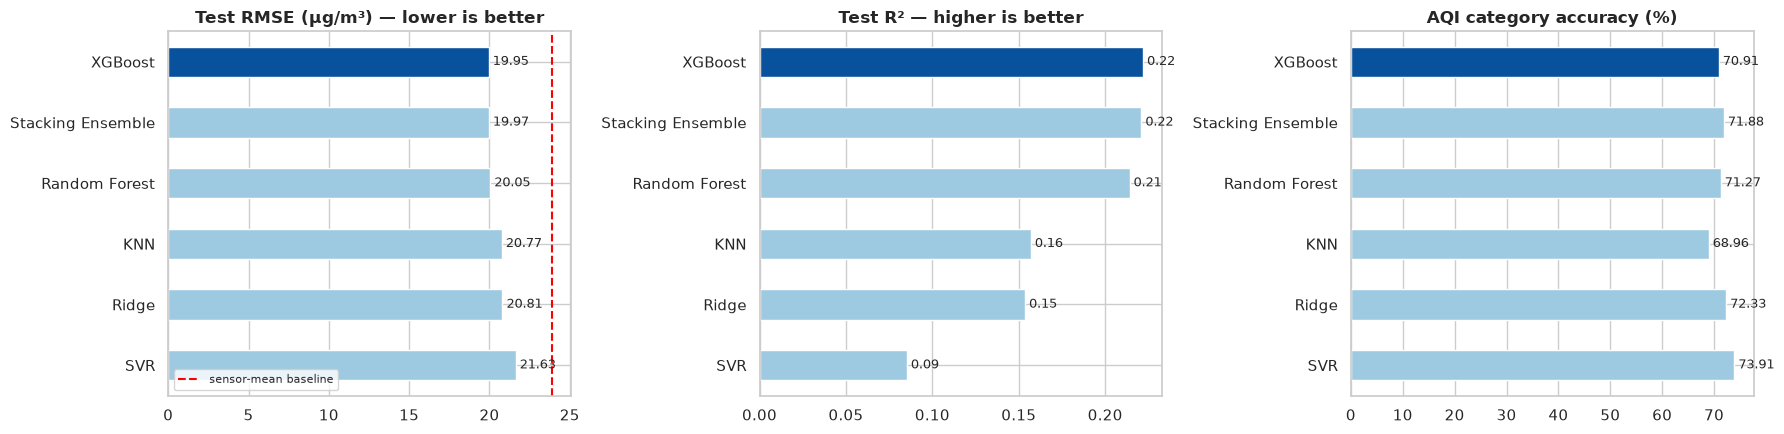

In [36]:
learned = comparison.drop(index=[i for i in comparison.index if i.startswith("Baseline")])
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
cols = ["#08519c" if i == learned.index[0] else "#9ecae1" for i in learned.index]
for ax, met, ttl in zip(axes, ["RMSE_ugm3", "R2", "AQI_accuracy_%"], ["Test RMSE (µg/m³) — lower is better", "Test R² — higher is better", "AQI category accuracy (%)"]):
    learned[met].plot.barh(ax=ax, color=cols, label="_nolegend_"); ax.set_title(ttl); ax.invert_yaxis(); ax.set_ylabel("")
    for i, v in enumerate(learned[met]): ax.text(v, i, f" {v:.2f}", va="center", fontsize=9)
    if met == "RMSE_ugm3":
        ax.axvline(comparison.loc["Baseline: sensor mean", "RMSE_ugm3"], color="red", ls="--", label="sensor-mean baseline"); ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); savefig(fig, "04a_model_comparison"); plt.show()

In [37]:
BEST_NAME = learned.index[0]
best_model = MODELS[BEST_NAME]
print(f"Best model on the hold-out test set: {BEST_NAME}")
print(comparison.loc[BEST_NAME].round(3).to_string())
logger.info(f"BEST MODEL = {BEST_NAME} | test RMSE_z={comparison.loc[BEST_NAME,'RMSE_z']:.4f} | R2={comparison.loc[BEST_NAME,'R2']:.4f}")

Best model on the hold-out test set: XGBoost
RMSE_z             0.703
MAE_z              0.432
R2                 0.222
RMSE_ugm3         19.954
MAE_ugm3          12.254
AQI_accuracy_%    70.908
CV_RMSE_z          0.718
train_RMSE_z       0.517
overfit_gap        0.187
fit_time_s        19.952
[03:30:30] BEST MODEL = XGBoost | test RMSE_z=0.7035 | R2=0.2219


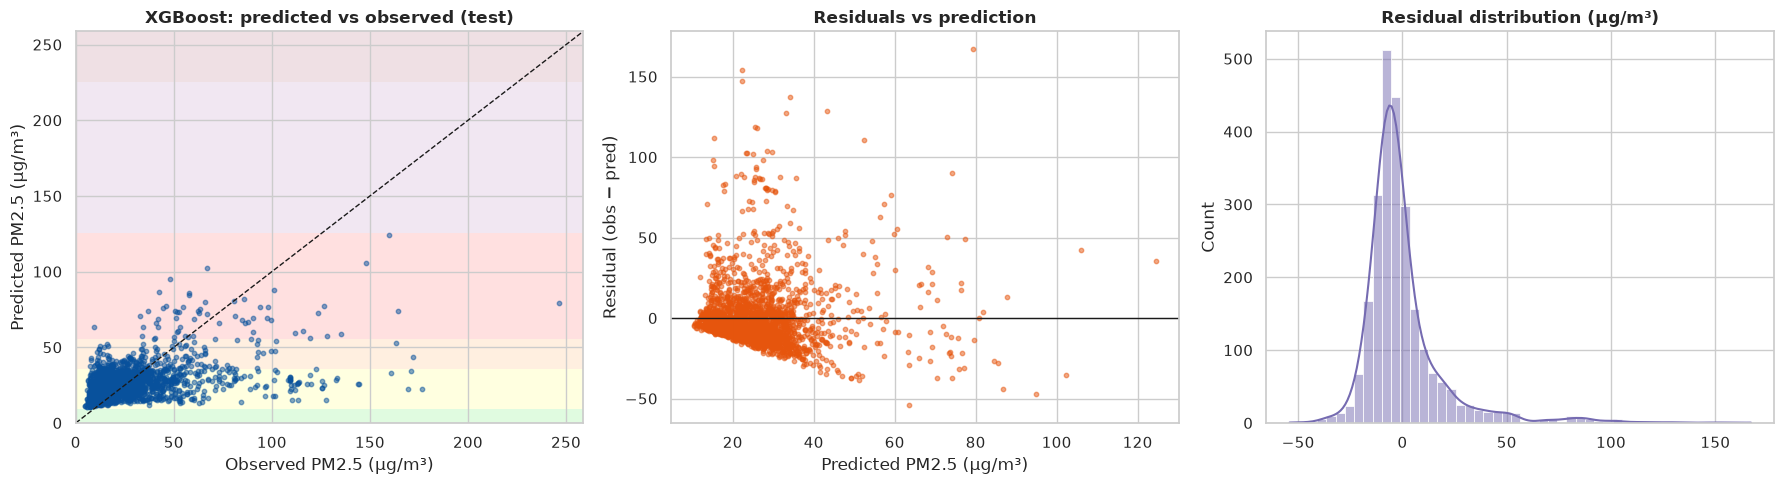

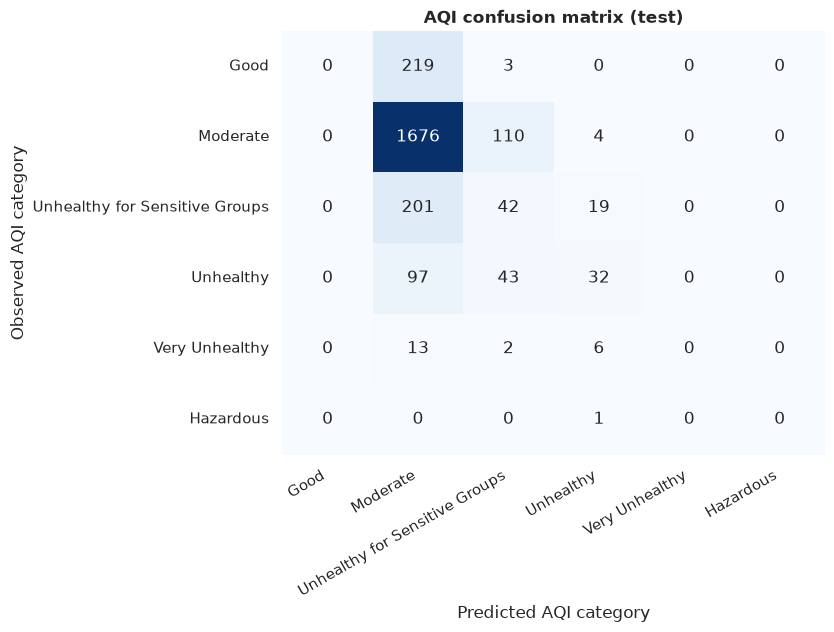

In [38]:
pred_test_z = best_model.predict(X_test)
true_ug, pred_ug = test_df.pm2_5.values, np.clip(pred_test_z * SIGMA + MU, 0, None)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lim = max(true_ug.max(), pred_ug.max()) * 1.05
add_aqi_bands(axes[0], lim, alpha=0.12)
axes[0].scatter(true_ug, pred_ug, s=10, alpha=0.5, color="#08519c"); axes[0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0].set_xlim(0, lim); axes[0].set_xlabel("Observed PM2.5 (µg/m³)"); axes[0].set_ylabel("Predicted PM2.5 (µg/m³)")
axes[0].set_title(f"{BEST_NAME}: predicted vs observed (test)")
resid = true_ug - pred_ug
axes[1].scatter(pred_ug, resid, s=10, alpha=0.5, color="#e6550d"); axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("Predicted PM2.5 (µg/m³)"); axes[1].set_ylabel("Residual (obs − pred)"); axes[1].set_title("Residuals vs prediction")
sns.histplot(resid, bins=50, kde=True, ax=axes[2], color="#756bb1"); axes[2].set_title("Residual distribution (µg/m³)")
plt.tight_layout(); savefig(fig, "04b_best_model_diagnostics"); plt.show()

from sklearn.metrics import confusion_matrix
cm_labels = [l for l in AQI_LABELS if l in set(aqi_category(true_ug).astype(str)) | set(aqi_category(pred_ug).astype(str))]
cm = confusion_matrix(aqi_category(true_ug).astype(str), aqi_category(pred_ug).astype(str), labels=cm_labels)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(pd.DataFrame(cm, index=cm_labels, columns=cm_labels), annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_xlabel("Predicted AQI category"); ax.set_ylabel("Observed AQI category"); ax.set_title("AQI confusion matrix (test)")
plt.xticks(rotation=30, ha="right"); savefig(fig, "04c_aqi_confusion"); plt.show()

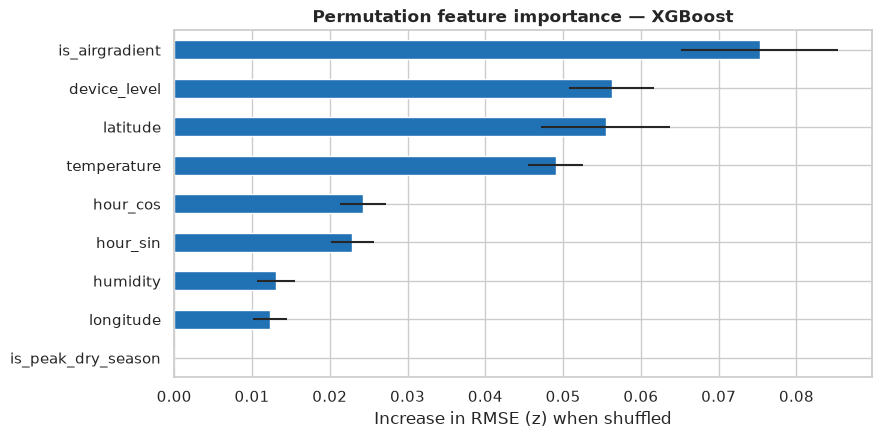

In [39]:
# Feature importance — permutation importance on the test set (model-agnostic: how much RMSE worsens when a feature is shuffled)
pi = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error")
FI = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
FI.plot.barh(ax=ax, color="#2171b5", xerr=pd.Series(pi.importances_std, index=FEATURES)[FI.index])
ax.set_title(f"Permutation feature importance — {BEST_NAME}"); ax.set_xlabel("Increase in RMSE (z) when shuffled")
savefig(fig, "04d_feature_importance"); plt.show()

### 4.6 Save the best model (serialised artifact)
The artifact bundles everything needed to make a prediction in µg/m³: the fitted model, the feature list, the target scaler (μ, σ) for the inverse Z-transform, the device encodings and the weather climatology used for forecasting.

In [40]:
# weather climatology per device and hour — needed to forecast future hours. June is the closest observed month to
# August (same Jun–Aug season); devices without June data fall back to their non-peak (Apr) values, then the network hour mean
jun = data[data.datetime.dt.month == 6]; nonpeak = data[peak_dry(data.datetime) == 0]
CLIM_DEV = (jun.groupby(["device_name", jun.datetime.dt.hour])[["temperature", "humidity"]].mean()
              .combine_first(nonpeak.groupby(["device_name", nonpeak.datetime.dt.hour])[["temperature", "humidity"]].mean()))
CLIM_HOUR = jun.groupby(jun.datetime.dt.hour)[["temperature", "humidity"]].mean()
SENSOR_META = hourly.groupby("device_name").agg(site_name=("site_name", "first"), network=("network", "first"),
                                                latitude=("latitude", "first"), longitude=("longitude", "first")).reset_index()
SENSOR_META["network"] = SENSOR_META["network"].astype(str)

artifact = {
    "model": best_model, "model_name": BEST_NAME, "features": FEATURES,
    "target_scaler": {"mu": float(MU), "sigma": float(SIGMA)},
    "device_encoding": DEVICE_ENC, "global_encoding": GLOBAL_ENC,
    "climatology_device_hour": CLIM_DEV, "climatology_hour": CLIM_HOUR, "sensor_meta": SENSOR_META,
    "aqi": {"bins": AQI_BINS, "labels": AQI_LABELS, "colors": AQI_COLORS},
    "best_params": BEST_PARAMS[BEST_NAME], "test_metrics": comparison.loc[BEST_NAME].to_dict(),
    "trained_at": datetime.now().isoformat(timespec="seconds"), "environment": ENV,
}
MODEL_PATH = MODEL_DIR / "best_pm25_model.joblib"
joblib.dump(artifact, MODEL_PATH, compress=3)
joblib.dump({"model": MODELS["Stacking Ensemble"], "features": FEATURES, "target_scaler": {"mu": float(MU), "sigma": float(SIGMA)},
             "device_encoding": DEVICE_ENC}, MODEL_DIR / "stacking_ensemble_pm25.joblib", compress=3)
with open(MODEL_DIR / "best_model_card.json", "w") as f:
    json.dump({"model_name": BEST_NAME, "best_params": {k: (v if isinstance(v, (int, float, str, dict, type(None))) else str(v)) for k, v in BEST_PARAMS[BEST_NAME].items()},
               "test_metrics": {k: round(float(v), 4) for k, v in comparison.loc[BEST_NAME].items() if pd.notna(v)},
               "features": FEATURES, "target": "global Z-score of PM2.5 (µg/m³)", "mu": MU, "sigma": SIGMA,
               "train_period": f"{train_df.datetime.min()} to {train_df.datetime.max()}", "test_period": f"{test_df.datetime.min()} to {test_df.datetime.max()}"},
              f, indent=2, default=str)
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size/1e6:.2f} MB)")

Saved /home/user/AirQo-AI_deployment/models/best_pm25_model.joblib  (0.98 MB)


## 5. Forecasting August 2026 with the saved model
The saved artifact is **re-loaded from disk** (proving it works standalone). Future feature values:
* hour of day, season flag (August = non-peak, like June), coordinates, device level, network — known in advance;
* temperature & humidity — unknown in advance, so we use each sensor's **June hour-of-day climatology** (June is the closest observed month to August; April values, then the network hour mean, where a sensor has no June data).

⚠️ Because none of these inputs change from one August day to the next, the model gives (almost) the same daily mean for a sensor every day: the forecast is a **climatological** forecast (typical level for that site, hour and season). The hourly forecast still shows the diurnal cycle. Day-to-day variation would come from feeding real weather forecasts. In production these would be replaced by a weather forecast (e.g. UNMA / Open-Meteo), which would add day-to-day variation.

Uncertainty: we attach a **±1·RMSE band** (from the hold-out test set) to every prediction.

In [41]:
def make_future_frame(art, start, end):
    idx = pd.date_range(start, end, freq="h")
    meta = art["sensor_meta"]
    fut = pd.MultiIndex.from_product([meta.device_name, idx], names=["device_name", "datetime"]).to_frame(index=False)
    fut = fut.merge(meta, on="device_name", how="left")
    fut["hour"] = fut.datetime.dt.hour
    clim = art["climatology_device_hour"].reset_index().rename(columns={"datetime": "hour"})
    fut = fut.merge(clim, on=["device_name", "hour"], how="left")
    ch = art["climatology_hour"]
    for c in ["temperature", "humidity"]:
        fut[c] = fut[c].fillna(fut.hour.map(ch[c]))
    return fut

def predict_ugm3(art, fut):
    X = build_features(fut, art["device_encoding"], art["global_encoding"])[art["features"]]
    z = art["model"].predict(X)
    out = fut[["device_name", "site_name", "latitude", "longitude", "datetime"]].copy()
    out["pred_z"] = z
    out["pred_pm25"] = np.clip(z * art["target_scaler"]["sigma"] + art["target_scaler"]["mu"], 0, None)   # inverse Z-score
    return out

with stage("5. forecasting"):
    art = joblib.load(MODEL_PATH)
    RMSE_UG = art["test_metrics"]["RMSE_ugm3"]
    fut_hourly = make_future_frame(art, f"{FC_DAILY_START} 00:00", f"{FC_DAILY_END} 23:00")
    pred_hourly_all = predict_ugm3(art, fut_hourly)

    # (a) DAILY forecast 1–16 Aug (daily mean of the 24 hourly predictions)
    daily_fc = (pred_hourly_all.assign(date=pred_hourly_all.datetime.dt.normalize())
                  .groupby(["device_name", "site_name", "latitude", "longitude", "date"], as_index=False)
                  .agg(pred_z=("pred_z", "mean"), pred_pm25=("pred_pm25", "mean")))
    daily_fc["lower"] = np.clip(daily_fc.pred_pm25 - RMSE_UG, 0, None); daily_fc["upper"] = daily_fc.pred_pm25 + RMSE_UG
    daily_fc["aqi_category"] = aqi_category(daily_fc.pred_pm25).astype(str)
    daily_fc.to_csv(FC_DIR / "daily_forecast_aug01_16_2026_all_sensors.csv", index=False)

    # (b) HOURLY forecast for 1 Aug 2026
    hourly_fc = pred_hourly_all[pred_hourly_all.datetime.dt.normalize() == FC_HOURLY_DAY].copy()
    hourly_fc["lower"] = np.clip(hourly_fc.pred_pm25 - RMSE_UG, 0, None); hourly_fc["upper"] = hourly_fc.pred_pm25 + RMSE_UG
    hourly_fc["aqi_category"] = aqi_category(hourly_fc.pred_pm25).astype(str)
    hourly_fc.to_csv(FC_DIR / "hourly_forecast_2026-08-01_all_sensors.csv", index=False)

print(f"Daily forecast rows: {len(daily_fc):,} ({daily_fc.device_name.nunique()} sensors × {daily_fc.date.nunique()} days)")
print(f"Hourly forecast rows: {len(hourly_fc):,} ({hourly_fc.device_name.nunique()} sensors × 24 h)")
print("\nInverse-transform check (first rows): pm25 = z × σ + μ with σ =", round(art['target_scaler']['sigma'], 3), "μ =", round(art['target_scaler']['mu'], 3))
daily_fc.head()

[03:30:35] START  5. forecasting


[03:30:35] END    5. forecasting  (0.2s)


Daily forecast rows: 2,384 (149 sensors × 16 days)
Hourly forecast rows: 3,576 (149 sensors × 24 h)

Inverse-transform check (first rows): pm25 = z × σ + μ with σ = 28.364 μ = 34.222


,device_name,site_name,latitude,longitude,date,pred_z,pred_pm25,lower,upper,aqi_category
0,ag_588c8125eca4,Kyebando,0.358762,32.584203,2026-08-01,0.552007,49.878506,29.92469,69.832321,Unhealthy for Sensitive Groups
1,ag_588c8125eca4,Kyebando,0.358762,32.584203,2026-08-02,0.552007,49.878506,29.92469,69.832321,Unhealthy for Sensitive Groups
2,ag_588c8125eca4,Kyebando,0.358762,32.584203,2026-08-03,0.552007,49.878506,29.92469,69.832321,Unhealthy for Sensitive Groups
3,ag_588c8125eca4,Kyebando,0.358762,32.584203,2026-08-04,0.552007,49.878506,29.92469,69.832321,Unhealthy for Sensitive Groups
4,ag_588c8125eca4,Kyebando,0.358762,32.584203,2026-08-05,0.552007,49.878506,29.92469,69.832321,Unhealthy for Sensitive Groups


In [42]:
print("Distribution of sensors by forecast AQI category (daily means, 1–16 Aug):")
daily_fc.aqi_category.value_counts().reindex(AQI_LABELS).fillna(0).astype(int)

Distribution of sensors by forecast AQI category (daily means, 1–16 Aug):


aqi_category
Good                                 0
Moderate                          2208
Unhealthy for Sensitive Groups     144
Unhealthy                           32
Very Unhealthy                       0
Hazardous                            0
Name: count, dtype: int64

### 5.1 Five forecast sensors, balanced across zones
One sensor per major zone: Kampala (central), Kampala metro (Kira/Wakiso), Jinja (east, industrial), Mbarara (west), Gulu (north) / Fort Portal.

In [43]:
def pick_zone(pattern, exclude=()):
    m = SENSOR_META[SENSOR_META.site_name.str.contains(pattern, case=False, regex=True) & ~SENSOR_META.device_name.isin(exclude)]
    cnt = data.groupby("device_name").size()
    m = m.assign(n=m.device_name.map(cnt).fillna(0)).sort_values("n", ascending=False)
    return m.device_name.iloc[0] if len(m) else None

ZONES = {"Kampala Central": "Civic Centre|Kampala Central|Nakasero|Buganda Road",
         "Kampala Metro (Kira/Wakiso)": "Kira Municipality|Wakiso",
         "Jinja (East)": "Jinja", "Mbarara (West)": "Mbarara", "Gulu (North)": "Gulu"}
FC_SENSORS = {}
for z, p in ZONES.items():
    d = pick_zone(p, exclude=list(FC_SENSORS.values()))
    if d: FC_SENSORS[z] = d
FC_LABEL = {d: f"{z.split(' (')[0]}: {SENSOR_META.set_index('device_name').site_name[d].split(',')[0][:22]}" for z, d in FC_SENSORS.items()}
FC_LABEL

{'aq_g5_37': 'Kampala Central: Civic Centre',
 'aq_58': 'Kampala Metro: Nansana east ward',
 'aq_23': 'Jinja: Jinja Main Street',
 'airqo-g5184': 'Mbarara: Mbarara University',
 'aq_g5_114': 'Gulu: Layibi Gulu'}

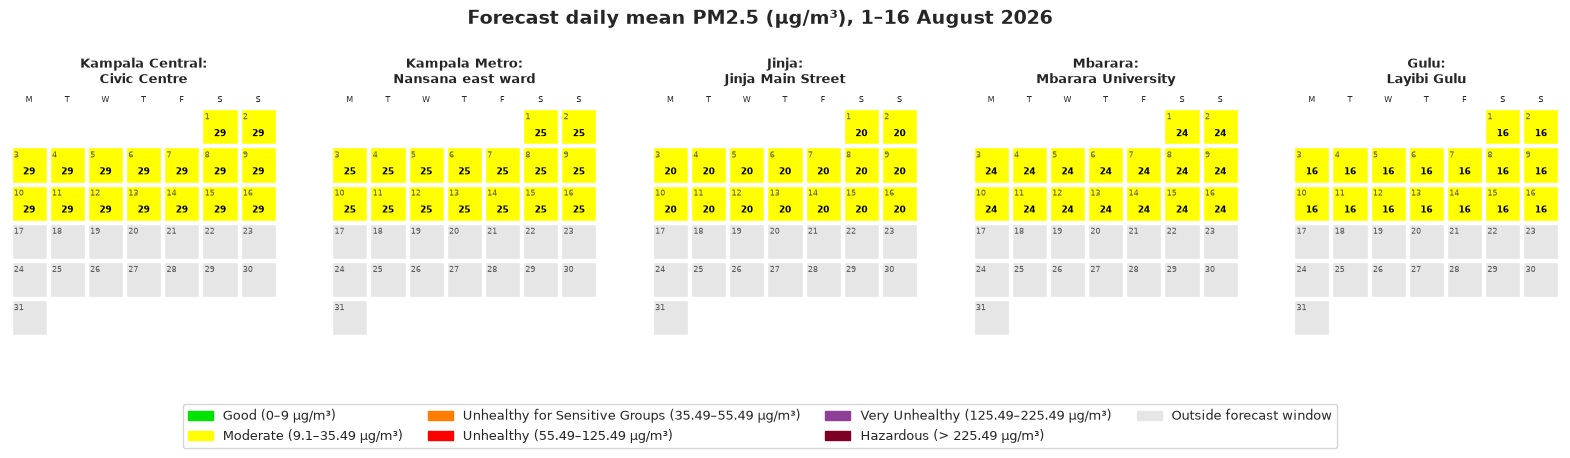

In [44]:
dsel = daily_fc[daily_fc.device_name.isin(FC_SENSORS.values())].copy()
dsel["label"] = dsel.device_name.map(FC_LABEL)

# Calendar plot of daily forecasts (Aug 2026) — one month grid per sensor
fig, axes = plt.subplots(1, len(FC_SENSORS), figsize=(4 * len(FC_SENSORS), 4.2))
for ax, d in zip(axes, FC_SENSORS.values()):
    ser = dsel[dsel.device_name == d].set_index("date").pred_pm25.to_dict()
    month_grid(ax, 2026, 8, ser, title=FC_LABEL[d].replace(": ", ":\n"))
fig.legend(handles=aqi_legend_handles() + [mpatches.Patch(color="#e6e6e6", label="Outside forecast window")],
           loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Forecast daily mean PM2.5 (µg/m³), 1–16 August 2026", fontsize=14, weight="bold")
savefig(fig, "05a_forecast_calendar"); plt.show()

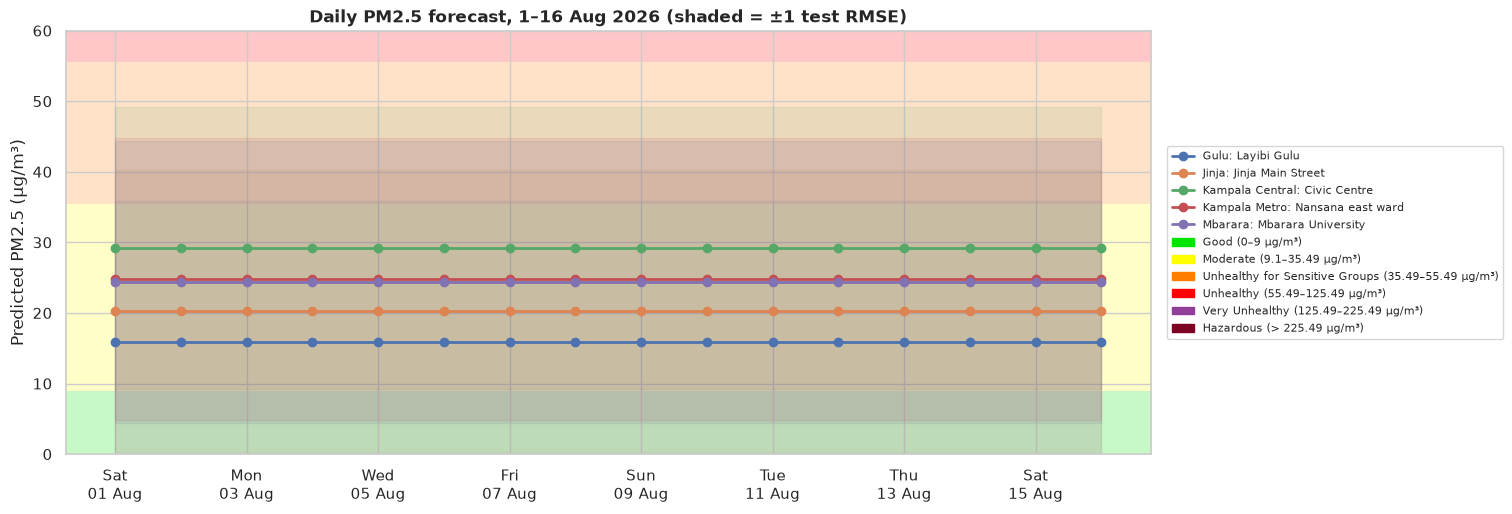

In [45]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ymax = max(60, dsel.upper.max() * 1.1)
add_aqi_bands(ax, ymax, alpha=0.22)
for lab, g in dsel.groupby("label"):
    l, = ax.plot(g.date, g.pred_pm25, marker="o", lw=2, label=lab)
    ax.fill_between(g.date, g.lower, g.upper, color=l.get_color(), alpha=0.12)
ax.set_ylabel("Predicted PM2.5 (µg/m³)"); ax.set_title("Daily PM2.5 forecast, 1–16 Aug 2026 (shaded = ±1 test RMSE)")
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%a\n%d %b"))
h, l = ax.get_legend_handles_labels()
ax.legend(h + aqi_legend_handles(), l + [p.get_label() for p in aqi_legend_handles()], fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
savefig(fig, "05b_forecast_daily_timeseries"); plt.show()

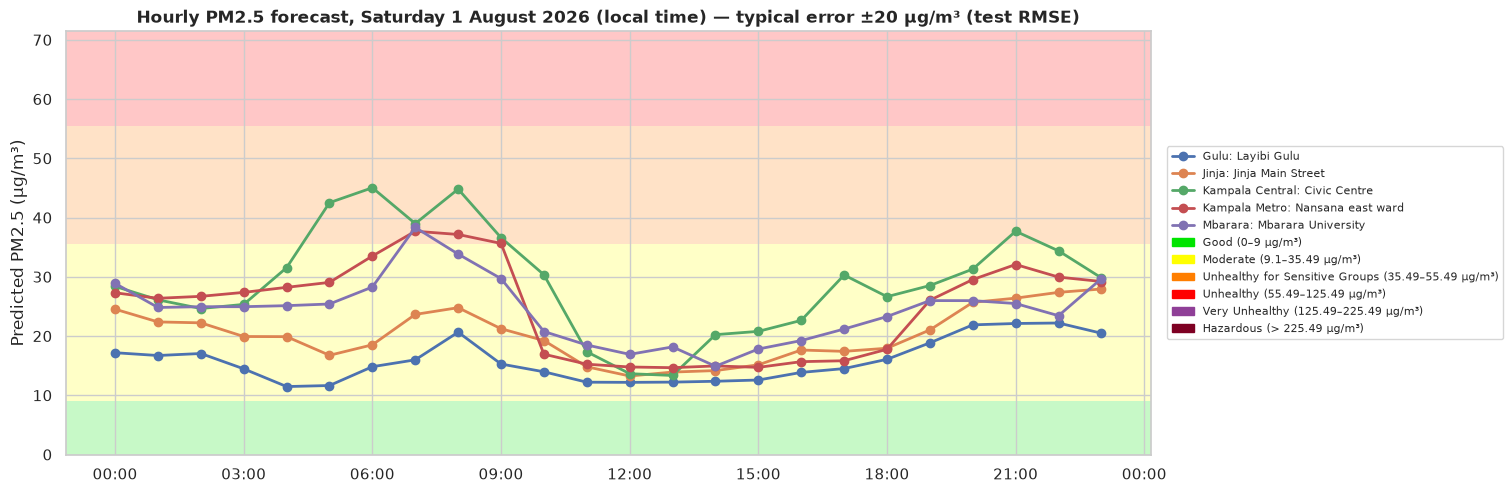

In [46]:
hsel = hourly_fc[hourly_fc.device_name.isin(FC_SENSORS.values())].copy()
hsel["label"] = hsel.device_name.map(FC_LABEL)
fig, ax = plt.subplots(figsize=(14, 5.5))
add_aqi_bands(ax, max(60, hsel.upper.max() * 1.1), alpha=0.22)
for lab, g in hsel.groupby("label"):
    l, = ax.plot(g.datetime, g.pred_pm25, marker="o", lw=2, label=lab)
ax.set_ylabel("Predicted PM2.5 (µg/m³)")
ax.set_title(f"Hourly PM2.5 forecast, Saturday 1 August 2026 (local time) — typical error ±{RMSE_UG:.0f} µg/m³ (test RMSE)")
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%H:%M"))
h, l = ax.get_legend_handles_labels()
ax.legend(h + aqi_legend_handles(), l + [p.get_label() for p in aqi_legend_handles()], fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
savefig(fig, "05c_forecast_hourly_aug01"); plt.show()

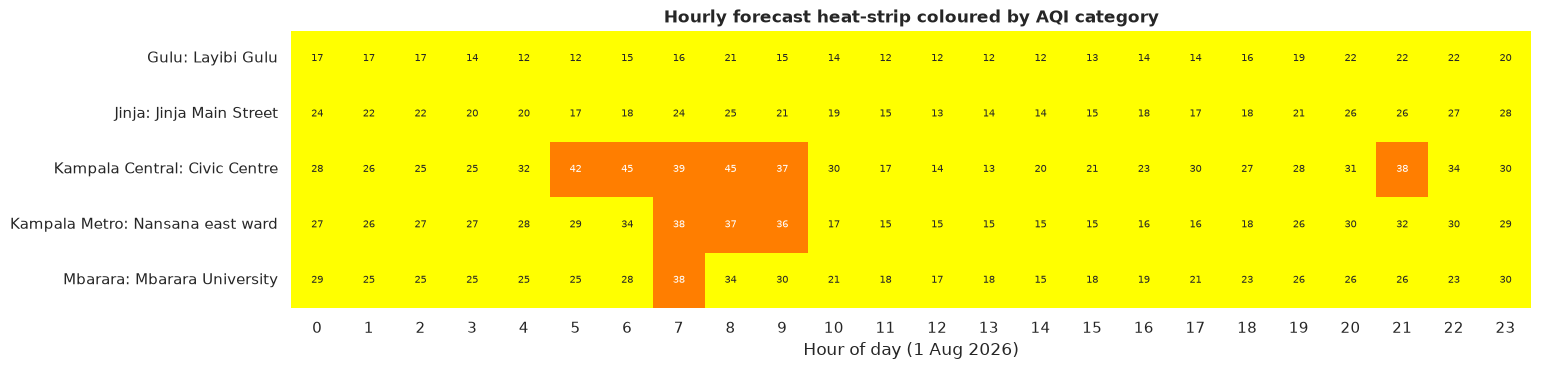

In [47]:
pivot_h = hsel.pivot_table(index="label", columns=hsel.datetime.dt.hour, values="pred_pm25").round(1)
fig, ax = plt.subplots(figsize=(16, 3.6))
sns.heatmap(pivot_h, cmap=aqi_cmap, norm=aqi_norm, annot=True, fmt=".0f", cbar=False, ax=ax, annot_kws={"fontsize": 7})
ax.set_xlabel("Hour of day (1 Aug 2026)"); ax.set_ylabel(""); ax.set_title("Hourly forecast heat-strip coloured by AQI category")
savefig(fig, "05d_forecast_hourly_heatstrip"); plt.show()

### 5.2 Bonus — map of sensors in the *Unhealthy for Sensitive Groups* → *Very Unhealthy* range at 13:00 on 1 Aug 2026
Uses Natural Earth shapefiles (country, districts, lakes) stored in `data/shapefiles/`.

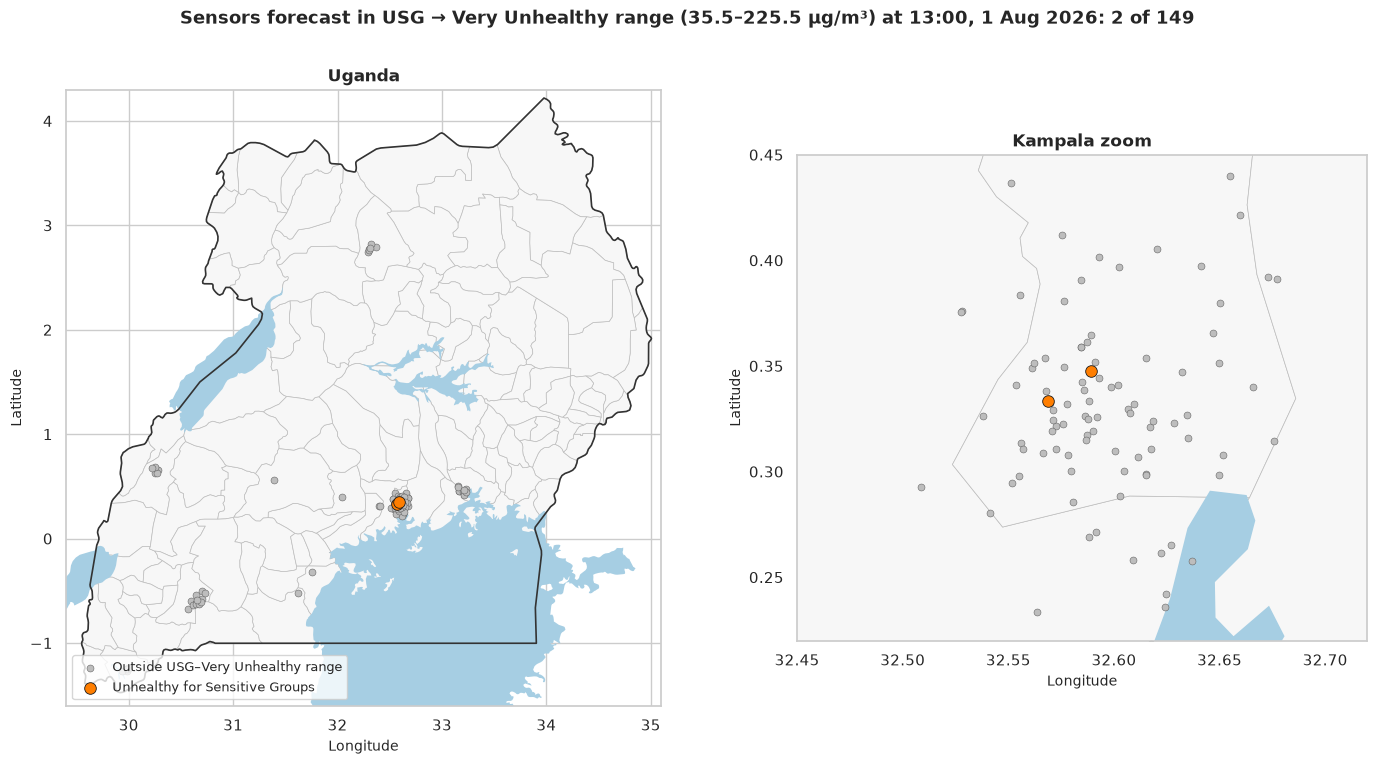

              site_name  pred_pm25                   aqi_category
  Sir Apollo Kagwa Road  50.400002 Unhealthy for Sensitive Groups
Kamwokya Primary School  37.200001 Unhealthy for Sensitive Groups


In [48]:
try:
    import geopandas as gpd
    at13 = hourly_fc[hourly_fc.datetime == pd.Timestamp(f"{FC_HOURLY_DAY} 13:00")].copy()
    at13["flag"] = at13.pred_pm25.between(AQI_BINS[2], AQI_BINS[5], inclusive="right")   # 35.49 < x <= 225.49
    at13["aqi_category"] = aqi_category(at13.pred_pm25).astype(str)
    gdf = gpd.GeoDataFrame(at13, geometry=gpd.points_from_xy(at13.longitude, at13.latitude), crs="EPSG:4326")
    ug = gpd.read_file(SHAPE_DIR / "uganda_boundary.shp"); dist = gpd.read_file(SHAPE_DIR / "uganda_districts.shp")
    lakes = gpd.read_file(SHAPE_DIR / "uganda_lakes.shp")
    fig, axes = plt.subplots(1, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [1.1, 1]})
    for ax, (xl, yl, ttl) in zip(axes, [((29.4, 35.1), (-1.6, 4.3), "Uganda"), ((32.45, 32.72), (0.22, 0.45), "Kampala zoom")]):
        dist.plot(ax=ax, color="#f7f7f7", edgecolor="#bdbdbd", lw=0.5); ug.boundary.plot(ax=ax, color="#333", lw=1.2)
        lakes.plot(ax=ax, color="#a6cee3", edgecolor="none")
        ok = gdf[~gdf.flag]; bad = gdf[gdf.flag]
        ok.plot(ax=ax, color="#bdbdbd", markersize=25, edgecolor="#666", lw=0.4, label="Outside USG–Very Unhealthy range")
        for cat, c in zip(AQI_LABELS[2:5], AQI_COLORS[2:5]):
            sub_ = bad[bad.aqi_category == cat]
            if len(sub_): sub_.plot(ax=ax, color=c, markersize=70, edgecolor="k", lw=0.6, label=f"{cat}")
        ax.set_xlim(*xl); ax.set_ylim(*yl); ax.set_title(ttl); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    axes[0].legend(loc="lower left", fontsize=9)
    fig.suptitle(f"Sensors forecast in USG → Very Unhealthy range (35.5–225.5 µg/m³) at 13:00, 1 Aug 2026: {int(gdf.flag.sum())} of {len(gdf)}",
                 fontsize=13, weight="bold")
    savefig(fig, "05e_bonus_map_13h"); plt.show()
    at13[at13.flag].sort_values("pred_pm25", ascending=False)[["site_name", "latitude", "longitude", "pred_pm25", "aqi_category"]].to_csv(
        FC_DIR / "sensors_usg_to_very_unhealthy_2026-08-01_13h.csv", index=False)
    print(at13[at13.flag].sort_values("pred_pm25", ascending=False)[["site_name", "pred_pm25", "aqi_category"]].head(15).round(1).to_string(index=False))
except Exception as e:
    logger.warning(f"Bonus map skipped: {e}")

## 6. Model monitoring with Evidently AI
* **Data drift** — compares the distribution of every input feature in the *reference* data (training period: Jan, Apr, 1–2 Jun) with the *current* data (test period: 2–3 Jun). For numeric columns Evidently uses the **Kolmogorov–Smirnov test** (small samples, ≤1000 rows) or **Wasserstein distance** (large samples); a column is "drifted" when the p-value < 0.05 (K-S) or the normalised distance > 0.1 (Wasserstein). The dataset is flagged as drifted when ≥ 50% of columns drift (`drift_share`).
* **Target drift / prediction drift** — the same tests on the true PM2.5 (Z) and on the model's predictions: target drift = the pollution regime itself changed (concept drift risk); prediction drift = the model's outputs shifted.
* **Model drift (performance)** — `RegressionPreset` computes RMSE, MAE, mean error (bias), MAPE, R² and max absolute error on reference vs current. Rising RMSE/MAE or a non-zero mean error on new data = model drift → retraining trigger.
* A second report compares **January (dry season) vs April (wet season)** to show what seasonal drift looks like.

*If Evidently fails (e.g. a dependency issue on RunPod), the block logs a warning and the pipeline continues.*

In [49]:
EVIDENTLY_SUMMARY = {}
def run_evidently(ref_df, cur_df, name, with_regression=True):
    from evidently import Dataset, DataDefinition, Report, Regression
    from evidently.presets import DataDriftPreset, RegressionPreset
    num_cols = FEATURES + (["target", "prediction"] if with_regression else [])
    dd = DataDefinition(numerical_columns=num_cols,
                        regression=[Regression(target="target", prediction="prediction")] if with_regression else None)
    ref = Dataset.from_pandas(ref_df[num_cols], data_definition=dd)
    cur = Dataset.from_pandas(cur_df[num_cols], data_definition=dd)
    presets = [DataDriftPreset()] + ([RegressionPreset()] if with_regression else [])
    snap = Report(presets).run(current_data=cur, reference_data=ref)
    snap.save_html(str(EV_DIR / f"{name}.html"))
    rows, other = [], {}
    for m in snap.dict()["metrics"]:
        cfg = m.get("config", {})
        if cfg.get("type", "").endswith("ValueDrift"):
            rows.append({"column": cfg["column"], "method": cfg["method"], "score": m["value"], "threshold": cfg["threshold"]})
        else:
            other[m["metric_name"].split("(")[0]] = m["value"]
    drift = pd.DataFrame(rows)
    if len(drift):
        is_p = drift.method.str.contains("p_value")
        drift["drifted"] = np.where(is_p, drift.score < drift.threshold, drift.score > drift.threshold)
    return drift, other

with stage("6. evidently monitoring"):
    try:
        ref_mon = X_train.copy(); ref_mon["target"] = y_train; ref_mon["prediction"] = best_model.predict(X_train)
        cur_mon = X_test.copy(); cur_mon["target"] = y_test; cur_mon["prediction"] = best_model.predict(X_test)
        DRIFT_TRAIN_TEST, perf_cur = run_evidently(ref_mon, cur_mon, "evidently_train_vs_test")
        _, perf_ref = run_evidently(ref_mon, ref_mon, "evidently_reference_self")
        jan = train_df.datetime.dt.month == 1; apr = train_df.datetime.dt.month == 4
        DRIFT_SEASON, _ = run_evidently(ref_mon[jan.values], ref_mon[apr.values], "evidently_jan_vs_apr_seasonal")
        EVIDENTLY_SUMMARY = {"drift_train_test": DRIFT_TRAIN_TEST, "drift_season": DRIFT_SEASON, "perf_ref": perf_ref, "perf_cur": perf_cur}
        print("Evidently reports written to", EV_DIR)
    except Exception as e:
        logger.warning(f"Evidently step skipped (pipeline continues): {e!r}")

[03:30:39] START  6. evidently monitoring


Evidently reports written to /home/user/AirQo-AI_deployment/outputs/evidently
[03:30:46] END    6. evidently monitoring  (6.9s)


,method,train→test score,train→test drifted,Jan→Apr score,Jan→Apr drifted
column,,,,,
hour_sin,Wasserstein distance (normed),0.0437,False,0.0460,False
hour_cos,Wasserstein distance (normed),0.0738,False,0.0267,False
is_peak_dry_season,Jensen-Shannon distance,0.4128,True,0.8326,True
latitude,Wasserstein distance (normed),0.0359,False,0.0403,False
longitude,Wasserstein distance (normed),0.0499,False,0.0689,False
temperature,Wasserstein distance (normed),0.2678,True,0.1191,True
humidity,Wasserstein distance (normed),0.3138,True,0.3547,True
is_airgradient,Jensen-Shannon distance,0.0239,False,0.0889,False
device_level,Wasserstein distance (normed),0.0757,False,0.0967,False


,reference (train),current (test),change
RMSE,0.5165,0.7035,0.1870
MAE,0.3513,0.4320,0.0807
MeanError,-0.0031,-0.0054,-0.0023
R2Score,0.7332,0.2219,-0.5113
AbsMaxError,5.9397,5.8896,-0.0501


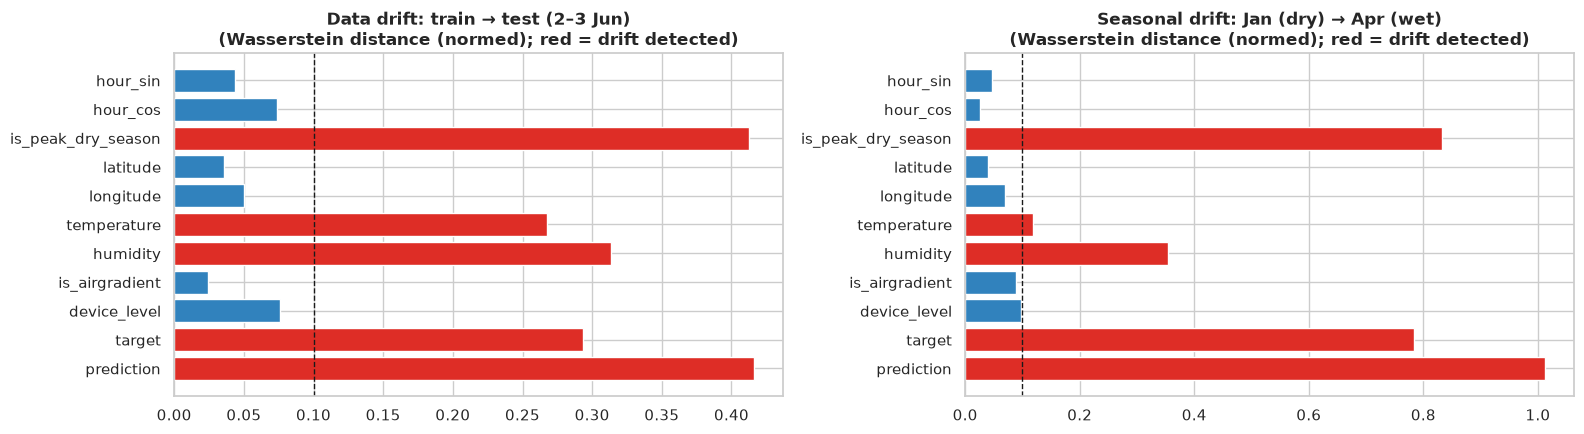

[03:30:46] Evidently: drifted columns train->test = 5/11


In [50]:
if EVIDENTLY_SUMMARY:
    d1 = EVIDENTLY_SUMMARY["drift_train_test"].set_index("column")[["method", "score", "drifted"]].rename(columns={"score": "train→test score", "drifted": "train→test drifted"})
    d2 = EVIDENTLY_SUMMARY["drift_season"].set_index("column")[["score", "drifted"]].rename(columns={"score": "Jan→Apr score", "drifted": "Jan→Apr drifted"})
    DRIFT_TABLE = d1.join(d2)
    display(DRIFT_TABLE.round(4))

    def _val(v):
        return v.get("mean", v) if isinstance(v, dict) else v
    keys = ["RMSE", "MAE", "MeanError", "R2Score", "AbsMaxError"]
    PERF_TABLE = pd.DataFrame({"reference (train)": [_val(EVIDENTLY_SUMMARY["perf_ref"].get(k, np.nan)) for k in keys],
                               "current (test)": [_val(EVIDENTLY_SUMMARY["perf_cur"].get(k, np.nan)) for k in keys]}, index=keys).astype(float)
    PERF_TABLE["change"] = PERF_TABLE["current (test)"] - PERF_TABLE["reference (train)"]
    display(PERF_TABLE.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
    plot_df = DRIFT_TABLE.copy()
    for ax, col, flag, ttl in zip(axes, ["train→test score", "Jan→Apr score"], ["train→test drifted", "Jan→Apr drifted"],
                                  ["Data drift: train → test (2–3 Jun)", "Seasonal drift: Jan (dry) → Apr (wet)"]):
        ax.barh(plot_df.index, plot_df[col], color=np.where(plot_df[flag], "#de2d26", "#3182bd"))
        meth = plot_df.method.iloc[0]
        ax.axvline(0.05 if "p_value" in meth else 0.1, color="k", ls="--", lw=1)
        ax.set_title(f"{ttl}\n({meth}; red = drift detected)"); ax.invert_yaxis()
    plt.tight_layout(); savefig(fig, "06a_evidently_drift"); plt.show()
    logger.info(f"Evidently: drifted columns train->test = {int(DRIFT_TABLE['train→test drifted'].sum())}/{len(DRIFT_TABLE)}")

**How to read the Evidently output for this problem**
* `hour_sin/hour_cos` should not drift (every period covers all hours) — if they did, the monitoring window would be incomplete (e.g. a sensor went offline at night).
* `temperature` / `humidity` drift between Jan and Apr is **expected seasonal drift** (wet season = cooler, more humid). When weather features drift, the model is extrapolating; if errors also rise, retrain with data from the new season.
* `is_peak_dry_season` drifts by construction between Jan and Apr (it is the season flag).
* `device_level`, `latitude`, `longitude` drifting means **the mix of online sensors changed** (devices went offline/online) — a data-pipeline/coverage issue rather than a change in the air.
* `target` drift = the pollution level itself changed (e.g. dry-season burning); `prediction` drift without target drift = the model reacts to input changes that do not affect real PM2.5.
* **Model drift**: compare RMSE/MAE/R² between reference and current. In production we would compute this daily as new labelled sensor data arrives and trigger retraining (and keep the previous model version for rollback — as noted in the team meeting) if RMSE grows by more than ~20% or the mean error (bias) moves away from 0.

## 7. Deployment on RunPod
**Steps followed (budget ≤ $5):**
1. runpod.io → *Pods* → *Deploy*. Select a **community-cloud** GPU priced well below $2/h (e.g. RTX A4000 / RTX 3090 / RTX 4090 at ≈ $0.2–0.7/h). Check the *Pod Summary* and *Pricing Summary* before deploying; choose **on-demand**, 20 GB container disk, 20 GB volume.
2. Template: **RunPod PyTorch 2.x** (Jupyter Lab pre-installed).
3. Open Jupyter Lab → upload this repository (or `git clone` it) → `pip install -r deployment/requirements.txt`.
4. *Run All* on this notebook (or `bash deployment/run_on_runpod.sh`, which executes it headless and saves the executed notebook + logs).
5. The pipeline detects the GPU (`nvidia-smi`) and trains XGBoost on CUDA; stage timings, metrics and environment are written to `outputs/logs/pipeline_run.log` and `outputs/logs/run_summary.json`.
6. Download `outputs/` and `models/` (full checklist in `deployment/RUNPOD_GUIDE.md`), take screenshots of the pod summary, billing and logs, then **stop and terminate the pod** to stop billing.

The cell below writes the run summary — run locally it documents local debugging; run on RunPod it records the pod ID, GPU and runtime.

In [51]:
TOTAL_RUNTIME = time.perf_counter() - PIPELINE_T0
run_summary = {
    "run_finished": datetime.now().isoformat(timespec="seconds"), "total_runtime_s": round(TOTAL_RUNTIME, 1),
    "stage_times_s": STAGE_TIMES, "environment": ENV, "best_model": BEST_NAME,
    "best_model_test_metrics": {k: round(float(v), 4) for k, v in comparison.loc[BEST_NAME].items() if pd.notna(v)},
    "all_models_test": comparison[["RMSE_z", "MAE_z", "R2", "RMSE_ugm3", "AQI_accuracy_%"]].round(4).to_dict(orient="index"),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "artifacts": {"model": str(MODEL_PATH.relative_to(ROOT)), "forecasts": str(FC_DIR.relative_to(ROOT)), "evidently": str(EV_DIR.relative_to(ROOT))},
}
suffix = "runpod" if "RUNPOD_POD_ID" in os.environ else "local"
with open(LOG_DIR / f"run_summary_{suffix}.json", "w") as f:
    json.dump(run_summary, f, indent=2, default=str)
logger.info(f"PIPELINE COMPLETE in {TOTAL_RUNTIME:.1f}s — summary written to run_summary_{suffix}.json")
pd.Series(STAGE_TIMES, name="seconds").to_frame()

[03:30:46] PIPELINE COMPLETE in 250.7s — summary written to run_summary_local.json


,seconds
1. load raw data,0.06
2. data preparation,0.05
2.6 hourly resampling,0.65
2.7 imputation,4.46
4. tune Ridge,1.97
4. tune KNN,3.35
4. tune SVR,10.34
4. tune Random Forest,146.20
4. tune XGBoost,19.95
4. stacking ensemble,21.54


## 8. Conclusions
* **Data**: the "Jan–Jul" file actually holds three 2–3 day windows; after resampling to a full hourly grid only ~2% of sensor-hours are observed. We treated offline hours as missing (never fabricated long-gap targets), interpolated only gaps ≤ 3 h, and imputed weather spatially.
* **EDA**: Kampala PM2.5 is right-skewed with a clear diurnal cycle (morning and evening peaks), mostly *Moderate* to *Unhealthy for Sensitive Groups*, with spikes into *Unhealthy*; temperature is negatively and humidity positively correlated with PM2.5.
* **Models**: all five tuned models and the stacking ensemble beat the global-mean baseline; the best model is selected by hold-out RMSE (see comparison table) and saved in `models/`.
* **Forecasts**: August 2026 is forecast from the saved model with an inverse Z-transform to µg/m³; most sensors are forecast *Moderate*, with several urban sites in *Unhealthy for Sensitive Groups* at the morning/evening peaks.
* **Limitations & next steps**: only 7 days of history → no weekday or long-term trend effect can be learned; August weather is climatological. Feeding real weather forecasts and continuous AirQo API data, retraining when Evidently flags drift, and versioning models for rollback are the natural production steps.

## References
1. Junninen, H., Niska, H., Tuppurainen, K., Ruuskanen, J., & Kolehmainen, M. (2004). Methods for imputation of missing values in air quality data sets. *Atmospheric Environment*, 38(18), 2895–2907.
2. Okure, D., Ssematimba, J., Sserunjogi, R., Gracia, N. L., Soppelsa, M. E., & Bainomugisha, E. (2022). Characterization of ambient air quality in selected urban areas in Uganda using low-cost sensing and measurement technologies. *Environmental Science & Technology*, 56(6), 3324–3339.
3. Adong, P., Bainomugisha, E., Okure, D., & Sserunjogi, R. (2022). Applying machine learning for large scale field calibration of low-cost PM2.5 and PM10 air pollution sensors. *Applied AI Letters*, 3(3), e76.
4. Barkjohn, K. K., Gantt, B., & Clements, A. L. (2021). Development and application of a United States-wide correction for PM2.5 data collected with the PurpleAir sensor. *Atmospheric Measurement Techniques*, 14(6), 4617–4637.
5. Roberts, D. R., Bahn, V., Ciuti, S., Boyce, M. S., Elith, J., Guillera-Arroita, G., et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40(8), 913–929.
6. World Health Organization (2021). *WHO global air quality guidelines: particulate matter (PM2.5 and PM10), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide.*
7. Evidently AI documentation — Data drift & regression presets (v0.7). https://docs.evidentlyai.com